# 🎮 League of Legends — Challenger Analytics

**Dataset:** `gptilt/lol-ultimate-events-challenger-10m` | **Region:** Americas | **Pipeline:** Preprocessing → Analysis → ML

## ⚙️ Setup & Configuration

In [4]:
import warnings, time, os, gc, ast
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from itertools import combinations
from collections import defaultdict
from tqdm.auto import tqdm

pd.set_option("display.float_format", "{:.4f}".format)
RANDOM_STATE = 42

DATASET_NAME   = "gptilt/lol-ultimate-events-challenger-10m"
SPLIT          = "train_region_americas"
TARGET_MATCHES = 300
OUTPUT_DIR     = "."

TEN_MS    = 600_000
TWENTY_MS = 1_200_000

USE_EXISTING_PARQUET = True
EXISTING_PARQUET     = "/content/events_805_matches.parquet"

print(f"USE_EXISTING_PARQUET = {USE_EXISTING_PARQUET}")
print("Config OK ✓")


USE_EXISTING_PARQUET = True
Config OK ✓


## 📥 Data Loading

In [5]:
BASE_COLS = [
    "matchId", "timestamp", "type",
    "killerTeamId", "participantId",
    "victimId", "killerId",
    "winningTeam",
    "monsterType", "monsterSubType",
    "buildingType", "towerType",
    "teamId",
    "gameVersion", "region",
]

def slot_cols(prefix):
    return [f"{prefix}_{i}" for i in range(1, 11)]

STAT_COLS = (
    slot_cols("totalGold")
    + slot_cols("xp")
    + slot_cols("minionsKilled")
    + slot_cols("jungleMinionsKilled")
    + slot_cols("championId")
    + slot_cols("level")
)

SELECTED = BASE_COLS + STAT_COLS
print(f"Selected {len(SELECTED)} columns")
print("inventoryIds, positionX/Y EXCLUDED ✓")
print(f"Target: {TARGET_MATCHES} complete matches")


Selected 75 columns
inventoryIds, positionX/Y EXCLUDED ✓
Target: 300 complete matches


In [6]:
if USE_EXISTING_PARQUET and os.path.exists(EXISTING_PARQUET):
    print(f"Loading existing parquet: {EXISTING_PARQUET}")
    events_df = pd.read_parquet(EXISTING_PARQUET)

    inv_cols = [c for c in events_df.columns if "inventoryId" in c or
                c in ("positionX", "positionY")]
    if inv_cols:
        events_df.drop(columns=inv_cols, inplace=True)
        print(f"Dropped {len(inv_cols)} unused columns: {inv_cols[:5]}...")

    for i in range(1, 11):
        col = f"level_{i}"
        if col not in events_df.columns:
            events_df[col] = np.nan

    print(f"events_df: {events_df.shape[0]:,} rows × {events_df.shape[1]} cols")
    print(f"Matches  : {events_df['matchId'].nunique():,}")
    print(f"Memory   : {events_df.memory_usage(deep=True).sum() / 1e6:.0f} MB")

else:
    from datasets import load_dataset

    match_buffer    = defaultdict(list)
    complete_matches = {}

    print("Streaming dari HuggingFace …")
    ds = load_dataset(DATASET_NAME, split=SPLIT, streaming=True)

    start = time.time()
    total_events = 0
    pbar = tqdm(desc="Events streamed", unit=" ev")

    for row in ds:
        match_id = row.get("matchId")
        if match_id is None:
            continue
        slim = {k: row.get(k) for k in SELECTED if k in row}
        match_buffer[match_id].append(slim)
        total_events += 1
        pbar.update(1)

        if row.get("type") == "GAME_END" and match_id not in complete_matches:
            complete_matches[match_id] = match_buffer.pop(match_id)
            if len(complete_matches) % 50 == 0:
                elapsed = time.time() - start
                pbar.set_postfix(complete=len(complete_matches),
                                 ev_per_s=f"{total_events/elapsed:.0f}")
            if len(complete_matches) >= TARGET_MATCHES:
                break

    pbar.close()
    del match_buffer
    gc.collect()

    print(f"Complete matches: {len(complete_matches):,}")
    print(f"Events streamed : {total_events:,}")
    print(f"Elapsed         : {(time.time()-start)/60:.1f} min")

    all_events = []
    for evlist in complete_matches.values():
        all_events.extend(evlist)
    events_df = pd.DataFrame(all_events)
    del all_events, complete_matches
    gc.collect()

    for col in ["timestamp","killerTeamId","killerId","victimId","participantId","winningTeam"]:
        if col in events_df.columns:
            events_df[col] = pd.to_numeric(events_df[col], errors="coerce")
    for col in STAT_COLS:
        if col in events_df.columns:
            events_df[col] = pd.to_numeric(events_df[col], errors="coerce").astype("float32")

    print(f"events_df: {events_df.shape[0]:,} rows × {events_df.shape[1]} cols")
    print(f"Memory   : {events_df.memory_usage(deep=True).sum() / 1e6:.0f} MB")


Streaming dari HuggingFace …


Resolving data files:   0%|          | 0/98 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/95 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/95 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Events streamed: 0 ev [00:00, ? ev/s]

Complete matches: 300
Events streamed : 372,957
Elapsed         : 87.1 min
events_df: 311,266 rows × 75 cols
Memory   : 198 MB


In [7]:
print("=" * 65)
ck = events_df[events_df["type"] == "CHAMPION_KILL"]
print(f"CHAMPION_KILL events       : {len(ck):,}")
print("killerTeamId dist          :", ck["killerTeamId"].value_counts(dropna=False).head(4).to_dict())

em = events_df[events_df["type"] == "ELITE_MONSTER_KILL"]
print(f"\nELITE_MONSTER_KILL events  : {len(em):,}")
print("monsterType (top 5)        :", em["monsterType"].value_counts(dropna=False).head(5).to_dict())
print("monsterSubType (top 5)     :", em["monsterSubType"].value_counts(dropna=False).head(5).to_dict())

print(f"\ntotalGold_1 null %         : {events_df['totalGold_1'].isna().mean()*100:.1f}%")
print(f"level_1 null %             : {events_df['level_1'].isna().mean()*100:.1f}%")
print("\nwinningTeam dist           :", events_df["winningTeam"].value_counts(dropna=False).head().to_dict())


CHAMPION_KILL events       : 15,275
killerTeamId dist          : {nan: 15275}

ELITE_MONSTER_KILL events  : 3,581
monsterType (top 5)        : {'HORDE': 1782, 'DRAGON': 1093, 'RIFTHERALD': 272, 'ATAKHAN': 236, 'BARON_NASHOR': 198}
monsterSubType (top 5)     : {None: 2488, 'AIR_DRAGON': 201, 'WATER_DRAGON': 180, 'CHEMTECH_DRAGON': 178, 'EARTH_DRAGON': 178}

totalGold_1 null %         : 0.0%
level_1 null %             : 0.0%

winningTeam dist           : {nan: 310966, 100.0: 160, 200.0: 140}


In [8]:
print("=" * 65)
print("DIAGNOSTIC: championId & teamId availability")
print("=" * 65)

champ_cols_check = [f"championId_{i}" for i in range(1, 11)]
present = [c for c in champ_cols_check if c in events_df.columns]
print(f"championId_1..10 columns present: {len(present)}/10")
for c in present[:3]:
    nn = events_df[c].notna().sum()
    print(f"  {c}: {nn:,} non-null rows / {len(events_df):,} total")

if "teamId" in events_df.columns:
    bk = events_df[events_df["type"] == "BUILDING_KILL"]
    print(f"\nteamId present. BUILDING_KILL rows: {len(bk):,}")
    print(f"  teamId non-null: {bk['teamId'].notna().sum():,}")
    print(f"  teamId dist: {bk['teamId'].value_counts(dropna=False).to_dict()}")
else:
    print("\n⚠️  'teamId' NOT in events_df — first-tower fix needs a re-stream")
    print("    with 'teamId' added to BASE_COLS (already added in Cell 5 of this")
    print("    notebook). If USE_EXISTING_PARQUET=True, the cached parquet was")
    print("    built BEFORE this fix and won't have it — set")
    print("    USE_EXISTING_PARQUET = False to re-stream, or regenerate the cache.")


DIAGNOSTIC: championId & teamId availability
championId_1..10 columns present: 10/10
  championId_1: 311,266 non-null rows / 311,266 total
  championId_2: 311,266 non-null rows / 311,266 total
  championId_3: 311,266 non-null rows / 311,266 total

teamId present. BUILDING_KILL rows: 3,719
  teamId non-null: 3,719
  teamId dist: {200.0: 1942, 100.0: 1777}


## 🗺️ Champion ID → Name Mapping

In [9]:
CHAMP_MAP = {
    0: "Unknown",
    1: "Annie", 2: "Olaf", 3: "Galio", 4: "Twisted Fate", 5: "Xin Zhao",
    6: "Urgot", 7: "LeBlanc", 8: "Vladimir", 9: "Fiddlesticks", 10: "Kayle",
    11: "Master Yi", 12: "Alistar", 13: "Ryze", 14: "Sion", 15: "Sivir",
    16: "Soraka", 17: "Teemo", 18: "Tristana", 19: "Warwick", 20: "Nunu & Willump",
    21: "Miss Fortune", 22: "Ashe", 23: "Tryndamere", 24: "Jax", 25: "Morgana",
    26: "Zilean", 27: "Singed", 28: "Evelynn", 29: "Twitch", 30: "Karthus",
    31: "Cho'Gath", 32: "Amumu", 33: "Rammus", 34: "Anivia", 35: "Shaco",
    36: "Dr. Mundo", 37: "Sona", 38: "Kassadin", 39: "Irelia", 40: "Janna",
    41: "Gangplank", 42: "Corki", 43: "Karma", 44: "Taric", 45: "Veigar",
    48: "Trundle", 50: "Swain", 51: "Caitlyn", 53: "Blitzcrank", 54: "Malphite",
    55: "Katarina", 56: "Nocturne", 57: "Maokai", 58: "Renekton", 59: "Jarvan IV",
    60: "Elise", 61: "Orianna", 62: "Wukong", 63: "Brand", 64: "Lee Sin",
    67: "Vayne", 68: "Rumble", 69: "Cassiopeia", 72: "Skarner", 74: "Heimerdinger",
    75: "Nasus", 76: "Nidalee", 77: "Udyr", 78: "Poppy", 79: "Gragas",
    80: "Pantheon", 81: "Ezreal", 82: "Mordekaiser", 83: "Yorick", 84: "Akali",
    85: "Kennen", 86: "Garen", 89: "Leona", 90: "Malzahar", 91: "Talon",
    92: "Riven", 96: "Kog'Maw", 98: "Shen", 99: "Lux",
    101: "Xerath", 102: "Shyvana", 103: "Ahri", 104: "Graves", 105: "Fizz",
    106: "Volibear", 107: "Rengar", 110: "Varus", 111: "Nautilus", 112: "Viktor",
    113: "Sejuani", 114: "Fiora", 115: "Ziggs", 117: "Lulu", 119: "Draven",
    120: "Hecarim", 121: "Kha'Zix", 122: "Darius", 126: "Jayce", 127: "Lissandra",
    131: "Diana", 133: "Quinn", 134: "Syndra", 136: "Aurelion Sol", 141: "Kayn",
    142: "Zoe", 143: "Zyra", 145: "Kai'Sa", 147: "Seraphine", 150: "Gnar",
    154: "Zac", 157: "Yasuo", 161: "Vel'Koz", 163: "Taliyah", 164: "Camille",
    166: "Akshan", 200: "Bel'Veth", 201: "Braum", 202: "Jhin", 203: "Kindred",
    221: "Zeri", 222: "Jinx", 223: "Tahm Kench", 233: "Briar", 234: "Viego",
    235: "Senna", 236: "Lucian", 238: "Zed", 240: "Kled", 245: "Ekko",
    246: "Qiyana", 254: "Vi", 266: "Aatrox", 267: "Nami", 268: "Azir",
    350: "Yuumi", 360: "Samira", 412: "Thresh", 420: "Illaoi", 421: "Rek'Sai",
    427: "Ivern", 429: "Kalista", 432: "Bard", 497: "Rakan", 498: "Xayah",
    516: "Ornn", 517: "Sylas", 518: "Neeko", 523: "Aphelios", 526: "Rell",
    555: "Pyke", 711: "Vex", 777: "Yone", 799: "Ambessa", 800: "Mel",
    804: "Yunara", 875: "Sett", 876: "Lillia", 887: "Gwen", 888: "Renata Glasc",
    893: "Aurora", 895: "Nilah", 897: "K'Sante", 901: "Smolder", 902: "Milio",
    904: "Zaahen", 910: "Hei", 950: "Naafiri",
}

def id_to_name(cid):
    try:
        return CHAMP_MAP.get(int(cid), f"Champ_{int(cid)}")
    except (ValueError, TypeError):
        return str(cid)

try:
    if "championId" in player_features.columns:
        player_features["champion"] = player_features["championId"].apply(id_to_name)
        print("✅ player_features champion column mapped")
except NameError:
    print("⚠️ player_features belum terdefinisi, skip.")

try:
    if "championId" in champ_stats.columns:
        champ_stats["champion"] = champ_stats["championId"].apply(id_to_name)
        print("✅ champ_stats champion column mapped")
except NameError:
    print("⚠️ champ_stats belum terdefinisi, skip.")

try:
    if "champ_a" in synergy_df.columns:
        synergy_df["name_a"] = synergy_df["champ_a"].apply(id_to_name)
        synergy_df["name_b"] = synergy_df["champ_b"].apply(id_to_name)
        synergy_df["pair"]   = synergy_df["name_a"] + " + " + synergy_df["name_b"]
        print("✅ synergy_df champion names mapped")
except NameError:
    print("⚠️ synergy_df belum terdefinisi, skip.")

print("✅ Champion ID → Name mapping ready (id_to_name tersedia)")

try:
    print(f"\n   champ_stats sample:")
    print(champ_stats[["championId", "champion", "picks", "win_rate"]].head(5).to_string(index=False))
except NameError:
    pass

try:
    print(f"\n   synergy top 5:")
    print(synergy_df[["pair", "co_picks", "pair_winrate", "synergy_score"]].head(5).to_string(index=False))
except NameError:
    pass

def propagate_champion_to_pf_clean():
    global pf_clean
    if "pf_clean" not in globals():
        print("⚠️ pf_clean belum terdefinisi.")
        return
    if "champion" in player_features.columns and "champion" not in pf_clean.columns:
        pf_clean = pf_clean.merge(
            player_features[["matchId", "participantSlot", "champion"]],
            on=["matchId", "participantSlot"],
            how="left"
        )
        print("✅ champion column propagated to pf_clean")


⚠️ player_features belum terdefinisi, skip.
⚠️ champ_stats belum terdefinisi, skip.
⚠️ synergy_df belum terdefinisi, skip.
✅ Champion ID → Name mapping ready (id_to_name tersedia)

   champ_stats sample:

   synergy top 5:


## ⚔️ Event Attribution

In [10]:
def assign_killer_team_vectorised(df):
    kt       = df["killerTeamId"].copy()
    valid_kt = kt.isin([100.0, 200.0])
    vid      = df["victimId"]
    fall_200 = (~valid_kt) & vid.between(1, 5)
    fall_100 = (~valid_kt) & vid.between(6, 10)
    result   = pd.Series(np.nan, index=df.index)
    result[valid_kt]  = kt[valid_kt]
    result[fall_200]  = 200.0
    result[fall_100]  = 100.0
    return result

kills_df   = events_df[events_df["type"] == "CHAMPION_KILL"].copy()
monster_df = events_df[events_df["type"] == "ELITE_MONSTER_KILL"].copy()
tower_df   = events_df[events_df["type"] == "BUILDING_KILL"].copy()

kills_df["killerTeam"]   = assign_killer_team_vectorised(kills_df)
monster_df["killerTeam"] = assign_killer_team_vectorised(monster_df)
tower_df["killerTeam"]   = assign_killer_team_vectorised(tower_df)

if "teamId" in tower_df.columns:
    still_missing = tower_df["killerTeam"].isna()
    has_team_id   = tower_df["teamId"].isin([100.0, 200.0])
    fix_mask      = still_missing & has_team_id
    tower_df.loc[fix_mask, "killerTeam"] = 300.0 - tower_df.loc[fix_mask, "teamId"]
    print(f"tower_df killerTeam recovered via teamId for {fix_mask.sum():,} rows")
else:
    print("'teamId' column not present in tower_df — re-stream with teamId added to BASE_COLS")

tower_by_match   = {mid: g for mid, g in tower_df.groupby("matchId")}

kills_by_match   = {mid: g for mid, g in kills_df.groupby("matchId")}
monster_by_match = {mid: g for mid, g in monster_df.groupby("matchId")}

print("Killer team assignment complete (vectorised) ✓")
print(f"  kills_df   : {len(kills_df):,} rows  | coverage {kills_df['killerTeam'].notna().mean():.1%}")
print(f"  monster_df : {len(monster_df):,} rows | coverage {monster_df['killerTeam'].notna().mean():.1%}")
print(f"  tower_df   : {len(tower_df):,} rows  | coverage {tower_df['killerTeam'].notna().mean():.1%}")

killer_id_rate = kills_df["killerId"].notna().mean() if "killerId" in kills_df.columns else 0.0
KILLS_PER_PLAYER_AVAILABLE = killer_id_rate > 0.5
print(f"  kills_df['killerId'] non-null: {killer_id_rate:.1%}")
if not KILLS_PER_PLAYER_AVAILABLE:
    print("  ⚠️  'killerId' tidak terisi untuk CHAMPION_KILL — kills per-PLAYER tidak")
    print("     dapat dihitung dari dataset ini. 'deaths' tetap valid (via victimId).")
    print("     player_features['kills'] akan konstan 0")


tower_df killerTeam recovered via teamId for 3,719 rows
Killer team assignment complete (vectorised) ✓
  kills_df   : 15,275 rows  | coverage 100.0%
  monster_df : 3,581 rows | coverage 99.8%
  tower_df   : 3,719 rows  | coverage 100.0%
  kills_df['killerId'] non-null: 0.0%
  ⚠️  'killerId' tidak terisi untuk CHAMPION_KILL — kills per-PLAYER tidak
     dapat dihitung dari dataset ini. 'deaths' tetap valid (via victimId).
     player_features['kills'] akan konstan 0


In [11]:
def get_stat_snapshot(match_events_df, cutoff_ms):
    """Last non-null gold snapshot at/before cutoff."""
    window = match_events_df[match_events_df["timestamp"] <= cutoff_ms]
    if len(window) == 0:
        return pd.Series(dtype=float)
    stat_rows = window[window["totalGold_1"].notna()]
    if len(stat_rows) == 0:
        return pd.Series(dtype=float)
    return stat_rows.iloc[-1]

def team_stat(snap, team, prefix):
    if len(snap) == 0:
        return 0.0
    slots = range(1, 6) if team == 100 else range(6, 11)
    return sum(float(snap.get(f"{prefix}_{i}", 0) or 0) for i in slots)

def team_cs(snap, team):
    if len(snap) == 0:
        return 0.0
    slots = range(1, 6) if team == 100 else range(6, 11)
    m  = sum(float(snap.get(f"minionsKilled_{i}", 0) or 0) for i in slots)
    jg = sum(float(snap.get(f"jungleMinionsKilled_{i}", 0) or 0) for i in slots)
    return m + jg

def team_jungle_cs(snap, team):
    if len(snap) == 0:
        return 0.0
    slots = range(1, 6) if team == 100 else range(6, 11)
    return sum(float(snap.get(f"jungleMinionsKilled_{i}", 0) or 0) for i in slots)

def team_level(snap, team):
    """Sum of player levels for a team at snapshot time."""
    if len(snap) == 0:
        return 0.0
    slots = range(1, 6) if team == 100 else range(6, 11)
    return sum(float(snap.get(f"level_{i}", 0) or 0) for i in slots)

print("Stat helpers defined ✓ (including level helper for P5)")


Stat helpers defined ✓ (including level helper for P5)


## 🛠️ Feature Engineering

In [12]:
feature_rows = []
match_ids    = events_df["matchId"].unique()

champ_cols_100 = [f"championId_{i}" for i in range(1, 6)]
champ_cols_200 = [f"championId_{i}" for i in range(6, 11)]

for match_id in tqdm(match_ids, desc="Building match_features"):
    mdf = events_df[events_df["matchId"] == match_id].sort_values("timestamp")

    wt_vals = mdf["winningTeam"].dropna()
    if len(wt_vals) == 0:
        continue
    winning_team = int(wt_vals.iloc[0])
    if winning_team not in (100, 200):
        continue
    win = int(winning_team == 100)

    game_version = mdf["gameVersion"].dropna().iloc[0] if mdf["gameVersion"].notna().any() else None
    region       = mdf["region"].dropna().iloc[0]      if mdf["region"].notna().any() else None
    duration_ms  = mdf["timestamp"].max()
    duration_min = duration_ms / 60_000

    s10 = get_stat_snapshot(mdf, TEN_MS)
    s20 = get_stat_snapshot(mdf, TWENTY_MS)

    gold_100_10 = team_stat(s10, 100, "totalGold")
    gold_200_10 = team_stat(s10, 200, "totalGold")
    gold_diff_10 = gold_100_10 - gold_200_10
    gold_diff_20 = team_stat(s20, 100, "totalGold") - team_stat(s20, 200, "totalGold")

    xp_100_10 = team_stat(s10, 100, "xp")
    xp_200_10 = team_stat(s10, 200, "xp")
    xp_diff_10   = xp_100_10 - xp_200_10
    xp_diff_20   = team_stat(s20, 100, "xp") - team_stat(s20, 200, "xp")

    xp_lead_pct_10 = (xp_100_10 / xp_200_10) if xp_200_10 > 0 else 1.0

    cs_diff_10         = team_cs(s10, 100) - team_cs(s10, 200)
    cs_diff_20         = team_cs(s20, 100) - team_cs(s20, 200)
    jungle_cs_diff_10  = team_jungle_cs(s10, 100) - team_jungle_cs(s10, 200)

    lvl_100_10   = team_level(s10, 100)
    lvl_200_10   = team_level(s10, 200)
    level_diff_10 = lvl_100_10 - lvl_200_10

    mk = kills_by_match.get(match_id, pd.DataFrame())
    if len(mk):
        k10 = mk[mk["timestamp"] <= TEN_MS]
        k20 = mk[mk["timestamp"] <= TWENTY_MS]
        kill_diff_10    = int((k10["killerTeam"] == 100).sum()) - int((k10["killerTeam"] == 200).sum())
        kill_diff_20    = int((k20["killerTeam"] == 100).sum()) - int((k20["killerTeam"] == 200).sum())
        total_kills     = len(mk)
        fb_row          = mk.sort_values("timestamp").iloc[0]
        fb_team         = fb_row["killerTeam"]
        first_blood_100 = int(fb_team == 100) if fb_team in (100, 200) else 0
    else:
        kill_diff_10 = kill_diff_20 = total_kills = first_blood_100 = 0

    mm = monster_by_match.get(match_id, pd.DataFrame())
    if len(mm):
        dragons = mm[mm["monsterType"] == "DRAGON"]
        barons  = mm[mm["monsterType"] == "BARON_NASHOR"]
        heralds = mm[mm["monsterType"] == "RIFTHERALD"]

        d10 = dragons[dragons["timestamp"] <= TEN_MS]
        d20 = dragons[dragons["timestamp"] <= TWENTY_MS]
        b20 = barons[barons["timestamp"]   <= TWENTY_MS]

        drag_diff_10  = int((d10["killerTeam"] == 100).sum()) - int((d10["killerTeam"] == 200).sum())
        drag_diff_20  = int((d20["killerTeam"] == 100).sum()) - int((d20["killerTeam"] == 200).sum())
        baron_diff_20 = int((b20["killerTeam"] == 100).sum()) - int((b20["killerTeam"] == 200).sum())
        total_dragons = len(dragons)
        total_barons  = len(barons)

        her_100 = int((heralds["killerTeam"] == 100).sum())
        her_200 = int((heralds["killerTeam"] == 200).sum())

        if len(heralds):
            fh_row          = heralds.sort_values("timestamp").iloc[0]
            first_herald_100 = int(fh_row["killerTeam"] == 100)
        else:
            first_herald_100 = 0

        fd_row  = dragons.sort_values("timestamp").iloc[0] if len(dragons) else None
        fd_team = fd_row["killerTeam"] if fd_row is not None else None
        first_dragon_100 = int(fd_team == 100) if fd_team in (100, 200) else 0

        d20_air   = int((d20["monsterSubType"].fillna("").str.contains("AIR")).sum() > 0)
        d20_fire  = int((d20["monsterSubType"].fillna("").str.contains("FIRE")).sum() > 0)
        d20_water = int((d20["monsterSubType"].fillna("").str.contains("WATER")).sum() > 0)
        d20_earth = int((d20["monsterSubType"].fillna("").str.contains("EARTH|MOUNTAIN")).sum() > 0)
    else:
        drag_diff_10 = drag_diff_20 = baron_diff_20 = 0
        total_dragons = total_barons = first_dragon_100 = 0
        her_100 = her_200 = first_herald_100 = 0
        d20_air = d20_fire = d20_water = d20_earth = 0

    mt = tower_by_match.get(match_id, pd.DataFrame())
    if len(mt):
        t10 = mt[mt["timestamp"] <= TEN_MS]
        t20 = mt[mt["timestamp"] <= TWENTY_MS]
        tower_diff_10 = int((t10["killerTeam"] == 100).sum()) - int((t10["killerTeam"] == 200).sum())
        tower_diff_20 = int((t20["killerTeam"] == 100).sum()) - int((t20["killerTeam"] == 200).sum())
        total_towers  = len(mt)
        ft_row        = mt.sort_values("timestamp").iloc[0]
        ft_team       = ft_row["killerTeam"]
        first_tower_100 = int(ft_team == 100) if ft_team in (100, 200) else 0
    else:
        tower_diff_10 = tower_diff_20 = total_towers = first_tower_100 = 0

    champ_cols_all = champ_cols_100 + champ_cols_200
    if len(mdf):
        champ_row = mdf[champ_cols_all].apply(
            lambda col: col.dropna().iloc[0] if col.notna().any() else np.nan
        )
    else:
        champ_row = pd.Series(index=champ_cols_all, dtype=float)
    team100_champs = [champ_row.get(f"championId_{i}") for i in range(1, 6)]
    team200_champs = [champ_row.get(f"championId_{i}") for i in range(6, 11)]

    feature_rows.append({
        "matchId":          match_id,
        "win":              win,
        "duration_min":     duration_min,
        "gameVersion":      game_version,
        "region":           region,
        "gold_diff_10":     gold_diff_10,
        "xp_diff_10":       xp_diff_10,
        "xp_lead_pct_10":   xp_lead_pct_10,
        "cs_diff_10":       cs_diff_10,
        "jungle_cs_diff_10": jungle_cs_diff_10,
        "kill_diff_10":     kill_diff_10,
        "tower_diff_10":    tower_diff_10,
        "dragon_diff_10":   drag_diff_10,
        "level_diff_10":    level_diff_10,
        "first_blood_100":  first_blood_100,
        "first_dragon_100": first_dragon_100,
        "first_tower_100":  first_tower_100,
        "first_herald_100": first_herald_100,
        "gold_diff_20":     gold_diff_20,
        "xp_diff_20":       xp_diff_20,
        "cs_diff_20":       cs_diff_20,
        "kill_diff_20":     kill_diff_20,
        "tower_diff_20":    tower_diff_20,
        "dragon_diff_20":   drag_diff_20,
        "baron_diff_20":    baron_diff_20,
        "total_kills":      total_kills,
        "total_dragons":    total_dragons,
        "total_barons":     total_barons,
        "total_towers":     total_towers,
        "herald_100":       her_100,
        "herald_200":       her_200,
        "d20_air":          d20_air,
        "d20_fire":         d20_fire,
        "d20_water":        d20_water,
        "d20_earth":        d20_earth,
        "team100_champs":   str([int(c) for c in team100_champs if pd.notna(c)]),
        "team200_champs":   str([int(c) for c in team200_champs if pd.notna(c)]),
    })

match_features = pd.DataFrame(feature_rows)
print(f"match_features: {match_features.shape}")
print("\nKey feature distributions:")
for col in ["kill_diff_10","level_diff_10","xp_lead_pct_10","first_herald_100","gold_diff_10"]:
    if col in match_features.columns:
        print(f"  {col}: mean={match_features[col].mean():.3f}  nonzero={(match_features[col]!=0).mean():.1%}")


Building match_features:   0%|          | 0/300 [00:00<?, ?it/s]

match_features: (300, 37)

Key feature distributions:
  kill_diff_10: mean=0.400  nonzero=89.0%
  level_diff_10: mean=0.070  nonzero=76.3%
  xp_lead_pct_10: mean=1.004  nonzero=100.0%
  first_herald_100: mean=0.537  nonzero=53.7%
  gold_diff_10: mean=155.297  nonzero=100.0%


In [13]:
champ_cols_100 = [f"championId_{i}" for i in range(1, 6)]
champ_cols_200 = [f"championId_{i}" for i in range(6, 11)]

champ_snap = (
    events_df.dropna(subset=["championId_1"])
    .groupby("matchId")[champ_cols_100 + champ_cols_200]
    .first()
    .reset_index()
)

all_champs = pd.Series(
    champ_snap[champ_cols_100 + champ_cols_200].values.ravel()
).dropna().astype(int).value_counts()
top30 = all_champs.head(30).index.tolist()

mf = match_features.merge(champ_snap, on="matchId", how="left")

for champ in top30:
    t100_cols = champ_cols_100
    t200_cols = champ_cols_200
    mf[f"team100_has_{champ}"] = mf[t100_cols].apply(
        lambda r: int(champ in r.dropna().astype(int).tolist()), axis=1
    )
    mf[f"team200_has_{champ}"] = mf[t200_cols].apply(
        lambda r: int(champ in r.dropna().astype(int).tolist()), axis=1
    )

mf["team100_top30_count"] = sum(mf[f"team100_has_{c}"] for c in top30)
mf["team200_top30_count"] = sum(mf[f"team200_has_{c}"] for c in top30)
mf["meta_pick_diff"]      = mf["team100_top30_count"] - mf["team200_top30_count"]

mf.drop(columns=champ_cols_100 + champ_cols_200, inplace=True, errors="ignore")
mf.fillna(0, inplace=True)
match_features = mf

champ_feat_cols = [c for c in match_features.columns if c.startswith("team100_has_") or
                   c.startswith("team200_has_")]
print(f"match_features with per-team champion flags: {match_features.shape}")
print(f"Champion feature columns: {len(champ_feat_cols)} (team100_has_X + team200_has_X)")
print(f"Top 5 champions tracked: {top30[:5]}")
print(f"\nP9 meta features: team100_top30_count, team200_top30_count, meta_pick_diff")


match_features with per-team champion flags: (300, 100)
Champion feature columns: 60 (team100_has_X + team200_has_X)
Top 5 champions tracked: [18, 202, 81, 267, 43]

P9 meta features: team100_top30_count, team200_top30_count, meta_pick_diff


In [14]:
print("Building player_features …")

dur_map = events_df.groupby("matchId")["timestamp"].max() / 60_000
player_rows = []

for match_id in tqdm(match_ids, desc="player_features"):
    mdf = events_df[events_df["matchId"] == match_id]
    dur = dur_map.get(match_id, 1)
    mk  = kills_by_match.get(match_id, pd.DataFrame())

    wt_vals = mdf["winningTeam"].dropna()
    if len(wt_vals) == 0:
        continue
    winning_team = int(wt_vals.iloc[0])

    end_snap = get_stat_snapshot(mdf, mdf["timestamp"].max())

    total_jg = sum(float(end_snap.get(f"jungleMinionsKilled_{i}", 0) or 0) for i in range(1, 11))

    for slot in range(1, 11):
        team = 100 if slot <= 5 else 200
        won  = int(team == winning_team)

        gold   = float(end_snap.get(f"totalGold_{slot}", 0) or 0)
        xp     = float(end_snap.get(f"xp_{slot}", 0) or 0)
        min_k  = float(end_snap.get(f"minionsKilled_{slot}", 0) or 0)
        jg_k   = float(end_snap.get(f"jungleMinionsKilled_{slot}", 0) or 0)
        champ  = end_snap.get(f"championId_{slot}")
        level  = float(end_snap.get(f"level_{slot}", 0) or 0)

        if len(mk):
            kills  = int((mk["killerId"] == slot).sum())
            deaths = int((mk["victimId"] == slot).sum())
        else:
            kills = deaths = 0

        kda = (kills + 0.5) / max(deaths, 1)

        jungle_share = jg_k / total_jg if total_jg > 0 else 0.0

        player_rows.append({
            "matchId":         match_id,
            "participantSlot": slot,
            "team":            team,
            "won":             won,
            "championId":      int(champ) if champ and not pd.isna(champ) else -1,
            "gold_pm":         gold / max(dur, 1),
            "xp_pm":           xp   / max(dur, 1),
            "cs_pm":           (min_k + jg_k) / max(dur, 1),
            "jungle_cs_pm":    jg_k / max(dur, 1),
            "jungle_share":    jungle_share,
            "kills":           kills,
            "deaths":          deaths,
            "kda_proxy":       kda,
            "gold_total":      gold,
            "level_end":       level,
            "duration_min":    dur,
        })

player_features = pd.DataFrame(player_rows)
print(f"player_features: {player_features.shape}")

if not globals().get("KILLS_PER_PLAYER_AVAILABLE", True):
    print("\n⚠️  player_features['kills'] = 0 untuk semua baris (killerId tidak terisi")
    print("   di dataset ini — lihat diagnostik Cell 12). 'deaths' & 'kda_proxy' tetap")
    print("   valid karena dihitung dari victimId. Fitur 'kills'/'kill_pm' tidak")
    print("   memberi informasi pada clustering/anomaly detection di bawah.")

player_features.describe().round(2)


Building player_features …


player_features:   0%|          | 0/300 [00:00<?, ?it/s]

player_features: (3000, 16)

⚠️  player_features['kills'] = 0 untuk semua baris (killerId tidak terisi
   di dataset ini — lihat diagnostik Cell 12). 'deaths' & 'kda_proxy' tetap
   valid karena dihitung dari victimId. Fitur 'kills'/'kill_pm' tidak
   memberi informasi pada clustering/anomaly detection di bawah.


,participantSlot,team,won,championId,gold_pm,xp_pm,cs_pm,jungle_cs_pm,jungle_share,kills,deaths,kda_proxy,gold_total,level_end,duration_min
count,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000
mean,5.5000,150.0000,0.5000,217.0400,386.8400,479.9000,5.9500,1.2800,0.1000,0.0000,5.0900,0.1500,10704.5500,14.3900,27.5400
std,2.8700,50.0100,0.5000,257.1900,83.6600,97.6000,2.6700,2.3600,0.1800,0.0000,2.9000,0.1300,3491.2300,2.6400,6.3100
min,1.0000,100.0000,0.0000,1.0000,163.1400,37.2800,0.0000,0.0000,0.0000,0.0000,0.0000,0.0300,1235.0000,4.0000,6.3300
25%,3.0000,100.0000,0.0000,51.0000,325.2100,413.2200,5.3100,0.0000,0.0000,0.0000,3.0000,0.0700,8162.2500,13.0000,23.8500
50%,5.5000,150.0000,0.5000,112.0000,385.7300,480.9500,6.7900,0.1000,0.0100,0.0000,5.0000,0.1000,10494.5000,15.0000,27.7700
75%,8.0000,200.0000,1.0000,245.0000,445.1100,550.5400,7.7500,0.5000,0.0400,0.0000,7.0000,0.1700,13085.2500,16.0000,31.3200
max,10.0000,200.0000,1.0000,950.0000,661.7100,774.6700,11.5500,9.3900,0.6500,0.0000,16.0000,0.5000,26493.0000,18.0000,49.6600


## 🔖 Patch Distribution & Robustness

PATCH DISTRIBUTION
Patch         Matches  % of total
-----------------------------------
  15.6             27  (  9.0%)  ██
  15.7            214  ( 71.3%)  ████████████████████
  15.8             59  ( 19.7%)  █████
-----------------------------------
  TOTAL           300

Patch unik       : 3
Patch dominan    : 15.7 (71.3% of dataset)

⚠️  PATCH DRIFT DETECTED: data berasal dari 3 patch berbeda.
   Meta LoL berubah setiap patch — champion strength, item build,
   dan objective value tidak konstan di seluruh dataset.
   Rekomendasi: pertimbangkan patch sebagai covariate atau filter
   analisis ke patch terbanyak untuk hasil lebih konsisten.


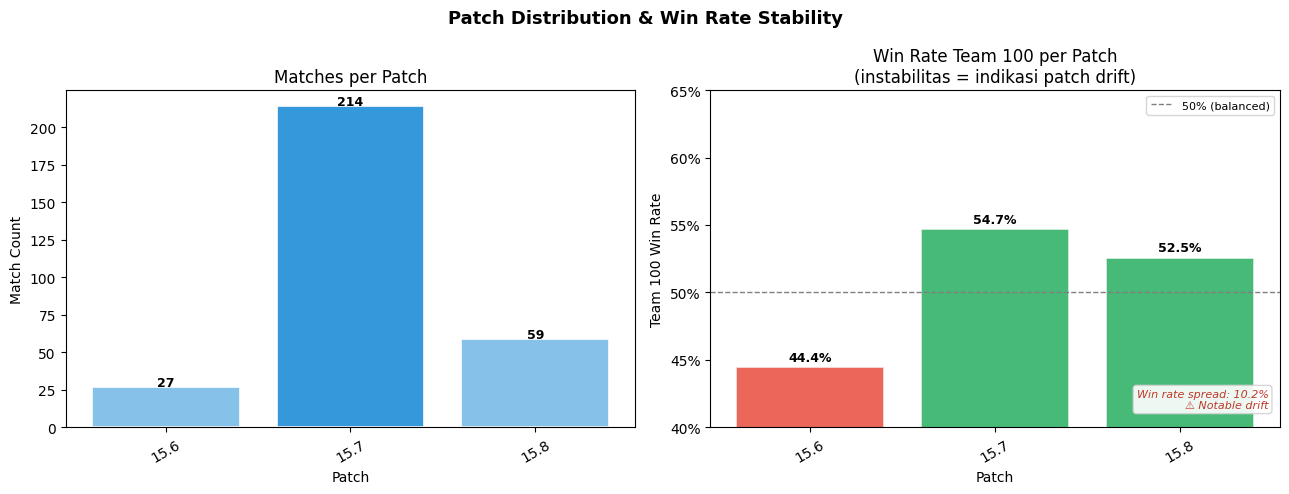


✅ viz_patch_distribution.png saved

Catatan untuk README/portfolio:
  Data berasal dari 3 patch berbeda (dominant: 15.7).
  Terdapat kemungkinan patch drift — champion winrate, objective value,
  dan feature importance dapat bergeser antar patch.
  Model perlu diinterpretasikan dalam konteks patch yang dianalisis.


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

if "gameVersion" in match_features.columns:
    match_features["patch"] = (
        match_features["gameVersion"]
        .astype(str)
        .str.extract(r"^(\d+\.\d+)", expand=False)
        .fillna("unknown")
    )
    patch_counts = match_features["patch"].value_counts().sort_index()

    print("=" * 55)
    print("PATCH DISTRIBUTION")
    print("=" * 55)
    print(f"{'Patch':<12} {'Matches':>8}  {'% of total':>10}")
    print("-" * 35)
    for patch, cnt in patch_counts.items():
        bar = "█" * int(cnt / patch_counts.max() * 20)
        print(f"  {patch:<10} {cnt:>8,}  ({cnt/len(match_features):>6.1%})  {bar}")
    print("-" * 35)
    print(f"  {'TOTAL':<10} {len(match_features):>8,}")

    n_patches = patch_counts.shape[0]
    dominant_patch = patch_counts.idxmax()
    dominant_pct   = patch_counts.max() / len(match_features)

    print(f"\nPatch unik       : {n_patches}")
    print(f"Patch dominan    : {dominant_patch} ({dominant_pct:.1%} of dataset)")

    if n_patches > 1:
        print(f"\n⚠️  PATCH DRIFT DETECTED: data berasal dari {n_patches} patch berbeda.")
        print("   Meta LoL berubah setiap patch — champion strength, item build,")
        print("   dan objective value tidak konstan di seluruh dataset.")
        print("   Rekomendasi: pertimbangkan patch sebagai covariate atau filter")
        print("   analisis ke patch terbanyak untuk hasil lebih konsisten.")
    else:
        print(f"\n✅ Dataset dari patch tunggal ({dominant_patch}) — tidak ada drift.")

    patch_wr = match_features.groupby("patch")["win"].agg(["mean", "count"]).reset_index()
    patch_wr.columns = ["patch", "win_rate", "n_matches"]
    patch_wr = patch_wr.sort_values("patch")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Patch Distribution & Win Rate Stability",
                 fontsize=13, fontweight="bold")

    ax1 = axes[0]
    colors = ["#3498db" if p == dominant_patch else "#85c1e9"
              for p in patch_wr["patch"]]
    bars = ax1.bar(patch_wr["patch"], patch_wr["n_matches"],
                   color=colors, edgecolor="white", linewidth=1.2)
    for bar, row in zip(bars, patch_wr.itertuples()):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{int(row.n_matches)}", ha="center", fontsize=9, fontweight="bold")
    ax1.set_xlabel("Patch")
    ax1.set_ylabel("Match Count")
    ax1.set_title("Matches per Patch")
    ax1.tick_params(axis="x", rotation=30)
    ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    ax2 = axes[1]
    ax2.bar(patch_wr["patch"], patch_wr["win_rate"],
            color=["#27ae60" if w > 0.5 else "#e74c3c" for w in patch_wr["win_rate"]],
            edgecolor="white", linewidth=1.2, alpha=0.85)
    ax2.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="50% (balanced)")
    for i, row in patch_wr.iterrows():
        ax2.text(i, row["win_rate"] + 0.005,
                 f"{row['win_rate']:.1%}", ha="center", fontsize=9, fontweight="bold")
    ax2.set_xlabel("Patch")
    ax2.set_ylabel("Team 100 Win Rate")
    ax2.set_title("Win Rate Team 100 per Patch\n(instabilitas = indikasi patch drift)")
    ax2.set_ylim(0.4, 0.65)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax2.tick_params(axis="x", rotation=30)
    ax2.legend(fontsize=8)

    if len(patch_wr) > 1:
        wr_range = patch_wr["win_rate"].max() - patch_wr["win_rate"].min()
        drift_label = (
            f"Win rate spread: {wr_range:.1%}\n"
            + ("⚠️ Notable drift" if wr_range > 0.05 else "✅ Stable across patches")
        )
        ax2.text(0.98, 0.05, drift_label, transform=ax2.transAxes,
                 ha="right", va="bottom", fontsize=8, style="italic",
                 color="#c0392b" if wr_range > 0.05 else "#27ae60",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                           edgecolor="lightgray", alpha=0.9))

    plt.tight_layout()
    plt.savefig("viz_patch_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n✅ viz_patch_distribution.png saved")
    print("\nCatatan untuk README/portfolio:")
    print(f"  Data berasal dari {n_patches} patch berbeda (dominant: {dominant_patch}).")
    print("  Terdapat kemungkinan patch drift — champion winrate, objective value,")
    print("  dan feature importance dapat bergeser antar patch.")
    print("  Model perlu diinterpretasikan dalam konteks patch yang dianalisis.")

else:
    print("⚠️  Kolom 'gameVersion' tidak ditemukan di match_features.")
    print("   Pastikan 'gameVersion' ada di BASE_COLS saat streaming HuggingFace (Cell 3).")
    print("   Kolom ini tersedia di dataset — cek dengan: events_df.columns.tolist()")


In [16]:
import pandas as pd, numpy as np

if "patch" not in match_features.columns:
    match_features["patch"] = (
        match_features["gameVersion"]
        .astype(str)
        .str.extract(r"^(\d+\.\d+)", expand=False)
        .fillna("unknown")
    )

patch_counts   = match_features["patch"].value_counts()
dominant_patch = patch_counts.idxmax()
dominant_pct   = patch_counts.max() / len(match_features)
n_patches      = patch_counts.shape[0]

print("=" * 60)
print("PATCH ROBUSTNESS ANALYSIS")
print("=" * 60)
print(f"Total patches     : {n_patches}")
print(f"Dominant patch    : {dominant_patch} ({dominant_pct:.1%} of dataset)")
print(f"Patch distribution:")
for p, cnt in patch_counts.items():
    print(f"  {p:<12} {cnt:>5,} matches  ({cnt/len(match_features):.1%})")

mf_dominant = match_features[match_features["patch"] == dominant_patch].copy()
mf_other    = match_features[match_features["patch"] != dominant_patch].copy()

print(f"\nDominant patch ({dominant_patch}): {len(mf_dominant):,} matches")
print(f"Other patches           : {len(mf_other):,} matches")

if len(mf_dominant) < 30:
    print("⚠️  Terlalu sedikit matches di dominant patch untuk analisis robust.")
    print("   Gunakan 2 patch teratas sebagai 'dominant' group.")
    top2 = patch_counts.head(2).index.tolist()
    mf_dominant = match_features[match_features["patch"].isin(top2)].copy()
    print(f"   Combined {top2}: {len(mf_dominant):,} matches")

print(f"\nWin balance per patch:")
patch_wr = match_features.groupby("patch")["win"].agg(["mean", "count"])
patch_wr.columns = ["win_rate", "n"]
wr_range = patch_wr["win_rate"].max() - patch_wr["win_rate"].min()
print(patch_wr.to_string())
print(f"\nWin rate spread across patches: {wr_range:.1%}")
if wr_range > 0.05:
    print("⚠️  Notable drift detected — patch mempengaruhi win balance.")
else:
    print("✅ Win balance stabil antar patch — drift minimal.")


PATCH ROBUSTNESS ANALYSIS
Total patches     : 3
Dominant patch    : 15.7 (71.3% of dataset)
Patch distribution:
  15.7           214 matches  (71.3%)
  15.8            59 matches  (19.7%)
  15.6            27 matches  (9.0%)

Dominant patch (15.7): 214 matches
Other patches           : 86 matches

Win balance per patch:
       win_rate    n
patch               
15.6     0.4444   27
15.7     0.5467  214
15.8     0.5254   59

Win rate spread across patches: 10.2%
⚠️  Notable drift detected — patch mempengaruhi win balance.


## 💾 Save Preprocessing to Parquet

In [17]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

mf_path = os.path.join(OUTPUT_DIR, "match_features.parquet")
pf_path = os.path.join(OUTPUT_DIR, "player_features.parquet")

match_features.to_parquet(mf_path,  index=False)
player_features.to_parquet(pf_path, index=False)

print("✅ Parquets saved:")
for p in [mf_path, pf_path]:
    size_kb = os.path.getsize(p) / 1024
    print(f"   {p}  ({size_kb:.0f} KB)")

print("\n✅ Preprocessing complete.")


✅ Parquets saved:
   ./match_features.parquet  (91 KB)
   ./player_features.parquet  (153 KB)

✅ Preprocessing complete.


---

# 📊 Part 2 — Analysis, Modelling & Visualisation

*Load parquets → EDA → ML → SHAP → Clustering → Anomaly → Synergy*

## 📦 Imports & Load Data

In [18]:
import warnings, os, ast
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
from itertools import combinations

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import shap

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("umap-learn tidak tersedia, gunakan PCA sebagai fallback")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
print("Analysis imports OK ✓")


Analysis imports OK ✓


In [19]:
DATA_DIR = "."

match_features  = pd.read_parquet(os.path.join(DATA_DIR, "match_features.parquet"))
player_features = pd.read_parquet(os.path.join(DATA_DIR, "player_features.parquet"))

cs_path = os.path.join(DATA_DIR, "champion_synergy.parquet")
cp_path = os.path.join(DATA_DIR, "champion_picks.parquet")

if os.path.exists(cs_path) and os.path.exists(cp_path):
    pair_stats  = pd.read_parquet(cs_path)
    champ_stats = pd.read_parquet(cp_path)
    print(f"pair_stats  loaded: {pair_stats.shape}")
    print(f"champ_stats loaded: {champ_stats.shape}")
else:
    pair_stats  = pd.DataFrame()
    champ_stats = pd.DataFrame()

print(f"match_features  : {match_features.shape}")
print(f"player_features : {player_features.shape}")

print("\nFeature non-zero rates:")
for col in ["kill_diff_10","level_diff_10","xp_lead_pct_10","first_herald_100","gold_diff_10"]:
    if col in match_features.columns:
        nz = (match_features[col] != 0).mean()
        print(f"  {col}: {nz:.1%} non-zero")


match_features  : (300, 101)
player_features : (3000, 16)

Feature non-zero rates:
  kill_diff_10: 89.0% non-zero
  level_diff_10: 76.3% non-zero
  xp_lead_pct_10: 100.0% non-zero
  first_herald_100: 53.7% non-zero
  gold_diff_10: 100.0% non-zero


## 🔍 Exploratory Data Analysis

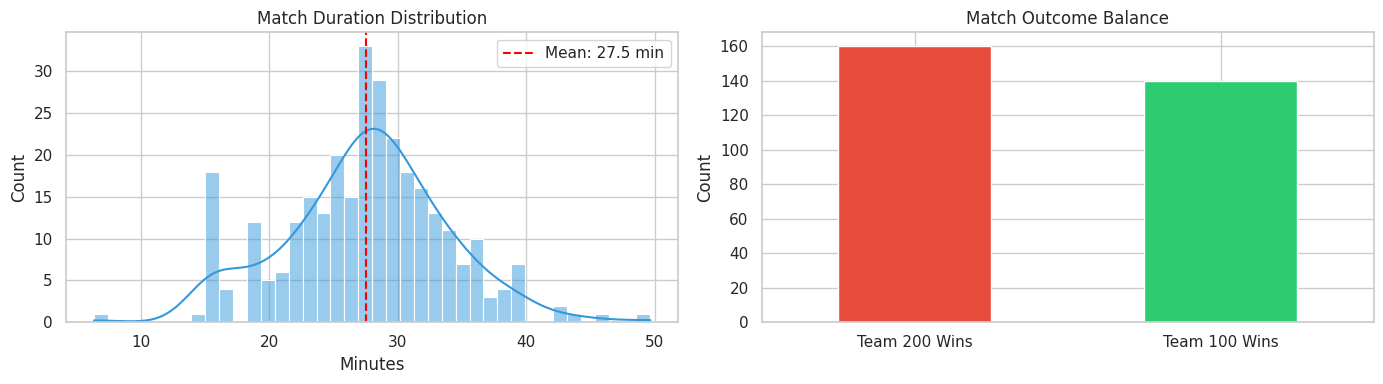

Matches          : 300
Mean duration    : 27.5 min
Team 100 win rate: 53.3%


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(match_features["duration_min"], bins=40, kde=True, ax=axes[0], color="#3498db")
axes[0].set_title("Match Duration Distribution")
axes[0].set_xlabel("Minutes")
axes[0].axvline(match_features["duration_min"].mean(), color="red", linestyle="--",
                label=f"Mean: {match_features['duration_min'].mean():.1f} min")
axes[0].legend()

win_counts = match_features["win"].value_counts()
win_counts.index = ["Team 200 Wins", "Team 100 Wins"]
win_counts.plot(kind="bar", ax=axes[1], color=["#e74c3c","#2ecc71"], rot=0)
axes[1].set_title("Match Outcome Balance")
axes[1].set_ylabel("Count")

plt.tight_layout(); plt.show()

print(f"Matches          : {len(match_features):,}")
print(f"Mean duration    : {match_features['duration_min'].mean():.1f} min")
print(f"Team 100 win rate: {match_features['win'].mean():.1%}")


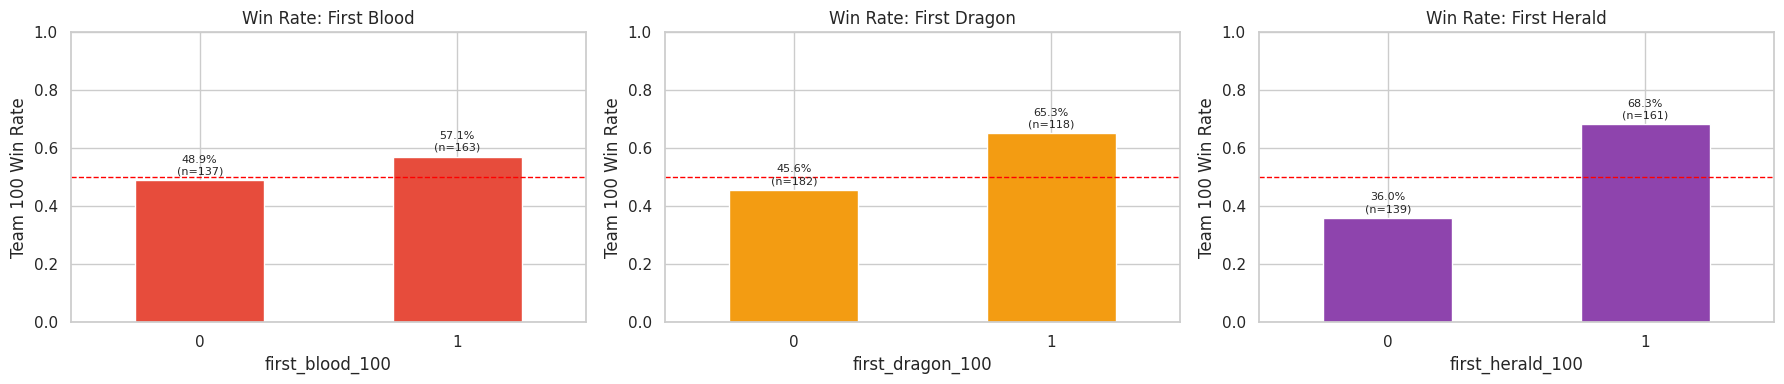

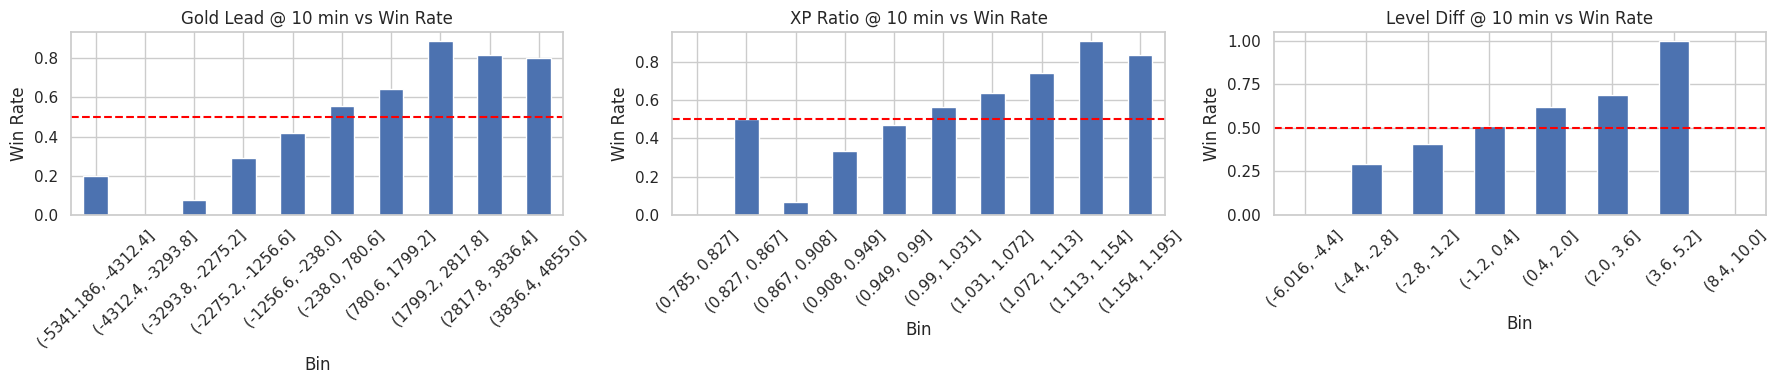

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

def plot_obj_wr(col, label, ax, color="steelblue"):
    wr = match_features.groupby(col)["win"].mean()
    n  = match_features.groupby(col).size()
    wr.plot(kind="bar", ax=ax, color=color, rot=0)
    ax.set_title(f"Win Rate: {label}")
    ax.set_ylabel("Team 100 Win Rate"); ax.set_ylim(0, 1)
    ax.axhline(0.5, color="red", linestyle="--", linewidth=1)
    for i, (v, cnt) in enumerate(zip(wr, n)):
        ax.text(i, v + 0.02, f"{v:.1%}\n(n={cnt})", ha="center", fontsize=8)

plot_obj_wr("first_blood_100",  "First Blood",  axes[0], "#e74c3c")
plot_obj_wr("first_dragon_100", "First Dragon", axes[1], "#f39c12")
plot_obj_wr("first_herald_100", "First Herald", axes[2], "#8e44ad")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for col, label, ax in [
    ("gold_diff_10",    "Gold Lead @ 10 min",  axes[0]),
    ("xp_lead_pct_10",  "XP Ratio @ 10 min",   axes[1]),
    ("level_diff_10",   "Level Diff @ 10 min",  axes[2]),
]:
    if col in match_features.columns:
        bins = pd.cut(match_features[col], bins=10)
        wr   = match_features.groupby(bins, observed=True)["win"].mean()
        wr.plot(kind="bar", ax=ax)
        ax.set_title(f"{label} vs Win Rate")
        ax.set_xlabel("Bin"); ax.set_ylabel("Win Rate")
        ax.axhline(0.5, color="red", linestyle="--")
        ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()


## 🤖 Machine Learning

In [22]:
EARLY_FEATURES = [
    "gold_diff_10", "xp_diff_10", "xp_lead_pct_10",
    "cs_diff_10", "jungle_cs_diff_10",
    "kill_diff_10", "tower_diff_10", "dragon_diff_10",
    "level_diff_10",
    "first_blood_100", "first_dragon_100", "first_tower_100",
    "first_herald_100",
]
FULL_FEATURES = EARLY_FEATURES + [
    "gold_diff_20", "xp_diff_20", "cs_diff_20",
    "kill_diff_20", "tower_diff_20", "dragon_diff_20", "baron_diff_20",
    "total_kills", "total_dragons", "total_barons", "total_towers",
    "herald_100", "herald_200",
    "d20_air", "d20_fire", "d20_water", "d20_earth",
]

CHAMP_FEATURES = [c for c in match_features.columns
                  if c.startswith("team100_has_") or c.startswith("team200_has_")]

META_FEATURES = ["team100_top30_count", "team200_top30_count", "meta_pick_diff"]

ALL_FEATURES = FULL_FEATURES + CHAMP_FEATURES + META_FEATURES
feature_cols = [c for c in ALL_FEATURES if c in match_features.columns]

X = match_features[feature_cols].fillna(0)
y = match_features["win"]

print(f"Features total : {len(feature_cols)}")
print(f"  - Core early : {len(EARLY_FEATURES)}")
print(f"  - Core full  : {len(FULL_FEATURES)}")
print(f"  - Champ (P7) : {len([c for c in CHAMP_FEATURES if c in match_features.columns])}")
print(f"  - Meta (P9)  : {len([c for c in META_FEATURES if c in match_features.columns])}")
print(f"Samples        : {len(X):,}")
print(f"Class balance  : {y.mean():.2%} (Team 100 wins)")
assert y.nunique() == 2, "Label has single class — cek winningTeam parsing"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")


Features total : 93
  - Core early : 13
  - Core full  : 30
  - Champ (P7) : 60
  - Meta (P9)  : 3
Samples        : 300
Class balance  : 53.33% (Team 100 wins)
Train: (240, 93)  Test: (60, 93)


In [23]:
def eval_model(name, y_true, y_pred, y_prob):
    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "ROC_AUC":   roc_auc_score(y_true, y_prob),
    }

BASELINE_FEATURES = ["gold_diff_10", "kill_diff_10", "first_blood_100"]
X_base_train = X_train[[c for c in BASELINE_FEATURES if c in X_train.columns]]
X_base_test  = X_test[[c  for c in BASELINE_FEATURES if c in X_test.columns]]

baseline_xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    random_state=RANDOM_STATE, verbosity=0)
baseline_xgb.fit(X_base_train, y_train)
base_prob = baseline_xgb.predict_proba(X_base_test)[:, 1]
base_pred = baseline_xgb.predict(X_base_test)
results = [eval_model("Baseline XGBoost (3 feats)", y_test, base_pred, base_prob)]

models = {
    "Logistic Regression": Pipeline([
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, C=0.1))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3, gamma=0.1,
        eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results.append(eval_model(name, y_test, pred, prob))
    trained_models[name] = model
    print(f"{name}: ROC-AUC = {results[-1]['ROC_AUC']:.4f}")

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
display(results_df.style.highlight_max(
    subset=["Accuracy","Precision","Recall","F1","ROC_AUC"], color="#d4edda"
))


Logistic Regression: ROC-AUC = 0.8683
Random Forest: ROC-AUC = 0.8973
XGBoost: ROC-AUC = 0.9007


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,XGBoost,0.800000,0.812500,0.812500,0.812500,0.900670
2,Random Forest,0.800000,0.794118,0.843750,0.818182,0.897321
1,Logistic Regression,0.800000,0.763158,0.906250,0.828571,0.868304
0,Baseline XGBoost (3 feats),0.583333,0.600000,0.656250,0.626866,0.650112


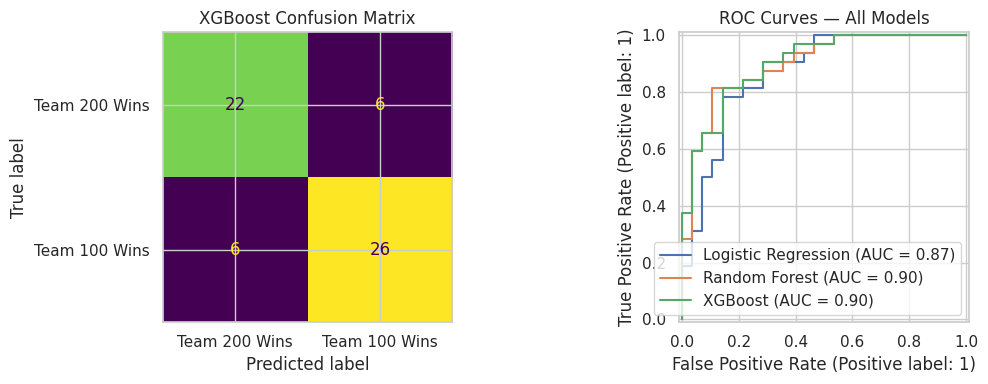

In [24]:
best_model = trained_models["XGBoost"]
best_pred  = best_model.predict(X_test)
best_prob  = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred, ax=axes[0],
    display_labels=["Team 200 Wins","Team 100 Wins"], colorbar=False)
axes[0].set_title("XGBoost Confusion Matrix")

for name, model in trained_models.items():
    prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[1])
axes[1].set_title("ROC Curves — All Models")

plt.tight_layout(); plt.show()


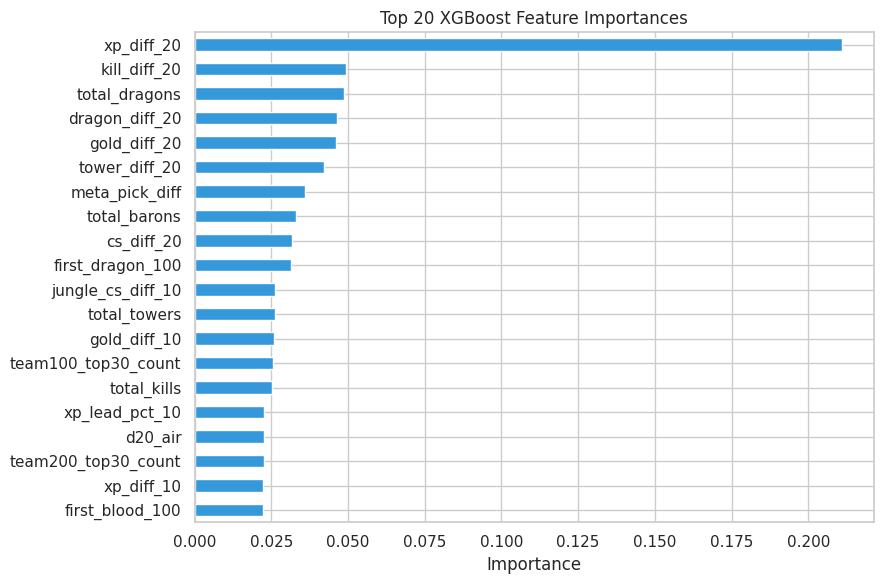

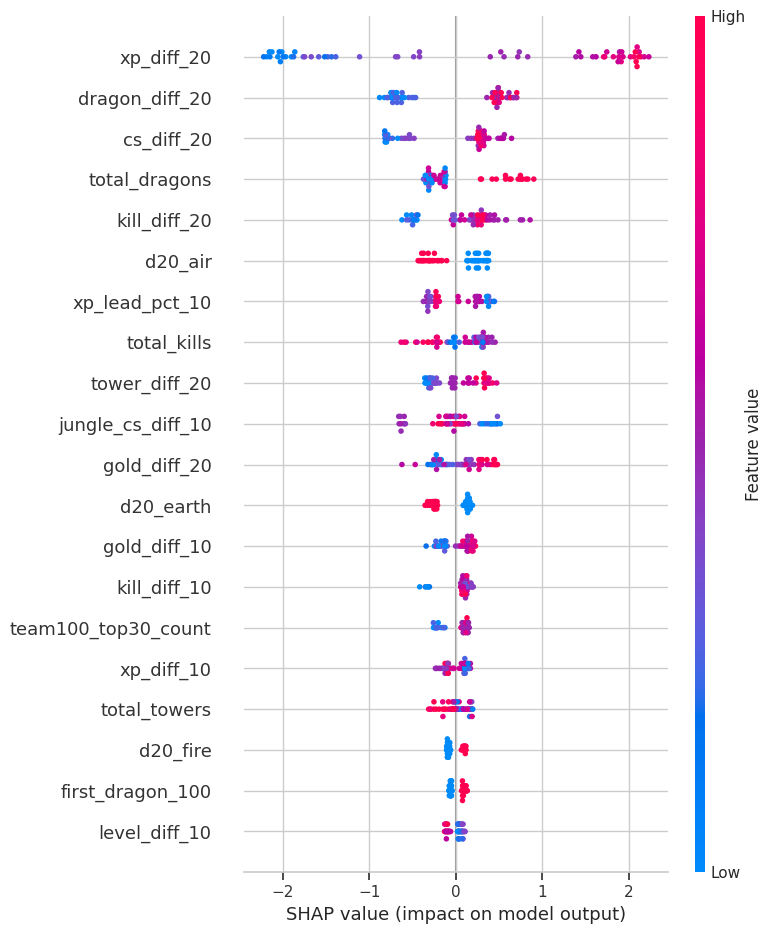


Top 10 SHAP features:
  xp_diff_20                          SHAP mean |value| = 1.6323
  dragon_diff_20                      SHAP mean |value| = 0.5963
  cs_diff_20                          SHAP mean |value| = 0.4551
  total_dragons                       SHAP mean |value| = 0.3409
  kill_diff_20                        SHAP mean |value| = 0.3340
  d20_air                             SHAP mean |value| = 0.2851
  xp_lead_pct_10                      SHAP mean |value| = 0.2780
  total_kills                         SHAP mean |value| = 0.2584
  tower_diff_20                       SHAP mean |value| = 0.2456
  jungle_cs_diff_10                   SHAP mean |value| = 0.2401

ℹ️  level_diff_10 rank: 20


In [25]:
importance = pd.Series(best_model.feature_importances_, index=X.columns)
top20 = importance.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Top 20 XGBoost Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

explainer   = shap.TreeExplainer(best_model)
sample_x    = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample_x)

shap.summary_plot(shap_values, sample_x, max_display=20, show=True)

shap_mean = pd.Series(np.abs(shap_values).mean(axis=0), index=sample_x.columns)
shap_mean = shap_mean.sort_values(ascending=False)
print("\nTop 10 SHAP features:")
for feat, val in shap_mean.head(10).items():
    print(f"  {feat:<35} SHAP mean |value| = {val:.4f}")
print()

if "level_diff_10" in shap_mean.head(10).index:
    rank = list(shap_mean.index).index("level_diff_10") + 1
    print(f"✅ level_diff_10 masuk Top-{rank} SHAP (P5 terbukti!)")
else:
    rank = list(shap_mean.index).index("level_diff_10") + 1 if "level_diff_10" in shap_mean.index else "N/A"
    print(f"ℹ️  level_diff_10 rank: {rank}")


## ⏱️ Early-Game Model (Leakage-Free)

*Only uses features ≤10 minutes — suitable for real-time prediction.*

In [26]:
drop_cols = [
    "matchId", "gameVersion", "region", "duration_min",
    "team100_champs", "team200_champs", "win",
    "patch",
    "dominant_patch",
]

obj_cols = [
    c for c in match_features.columns
    if match_features[c].dtype == object and c not in drop_cols
]
if obj_cols:
    print(f"⚠️  Kolom object tambahan yang ikut di-drop: {obj_cols}")
    drop_cols += obj_cols

features = [c for c in match_features.columns if c not in drop_cols]
early_features = [c for c in features if "_20" not in c]

print(f"All features   : {len(features)}")
print(f"Early features : {len(early_features)}")
print(f"Dropped cols   : {[c for c in drop_cols if c in match_features.columns]}")


All features   : 93
Early features : 81
Dropped cols   : ['matchId', 'gameVersion', 'region', 'duration_min', 'team100_champs', 'team200_champs', 'win', 'patch']


In [27]:
X_early = match_features[early_features].fillna(0)
y_early = match_features["win"]

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_early, y_early,
    test_size=0.2,
    random_state=42,
    stratify=y_early
)

early_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

early_model.fit(X_train_e, y_train_e)

pred_e    = early_model.predict_proba(X_test_e)[:, 1]
auc_early = roc_auc_score(y_test_e, pred_e)

print("EARLY GAME AUC =", round(auc_early, 4))


EARLY GAME AUC = 0.6864


## 🔎 Leakage & Feature Audit

AUDIT 1A: Data Leakage Check

Fitur total di model saat ini : 93
Fitur menit-20 yang dipakai   : 17
  ⚠️  LEAKAGE TERDETEKSI — fitur ini tidak tersedia di menit ke-10:
     • gold_diff_20
     • xp_diff_20
     • cs_diff_20
     • kill_diff_20
     • tower_diff_20
     • dragon_diff_20
     • baron_diff_20
     • total_kills
     • total_dragons
     • total_barons
     • total_towers
     • herald_100
     • herald_200
     • d20_air
     • d20_fire
     • d20_water
     • d20_earth

→ Model FULL bukan 'early game predictor' — ini mid-game predictor.
→ Audit 1B di bawah memisahkan keduanya.

AUDIT 1B: Early Game (10m) vs Mid Game (20m) vs Full Model
------------------------------------------------------------
  Early Game Model (≤10 min)          ROC-AUC = 0.6808
  Mid Game Model  (≤20 min)           ROC-AUC = 0.9018
  Full Model (all features)           ROC-AUC = 0.9007

AUC Gain 10m→20m : +0.2210
AUC Gain 20m→Full: +-0.0011

⚠️  GAP BESAR: fitur menit-20 memberikan info signifikan.


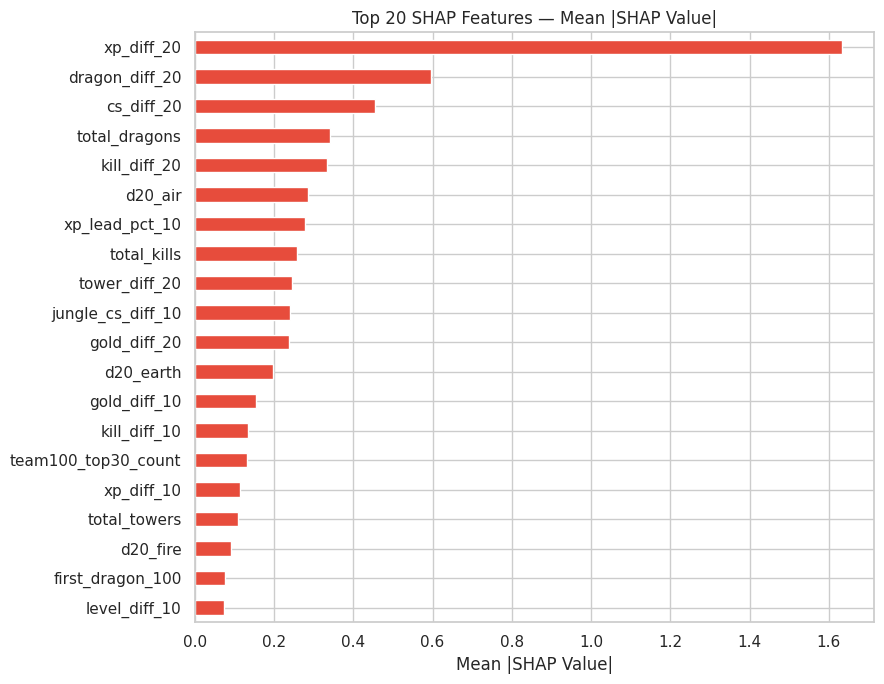

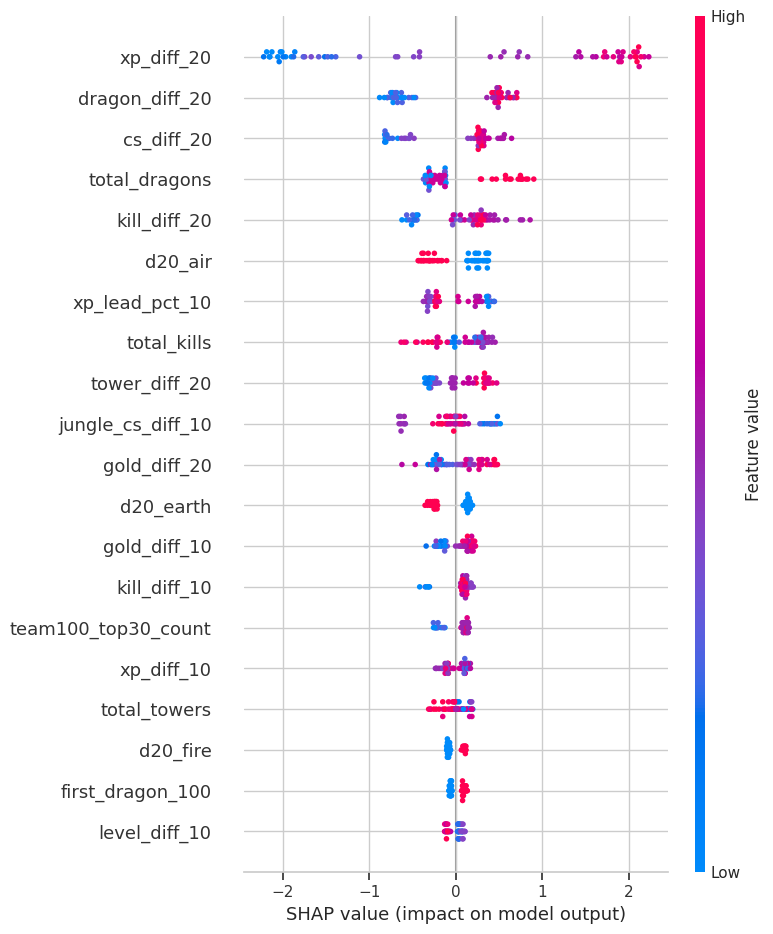

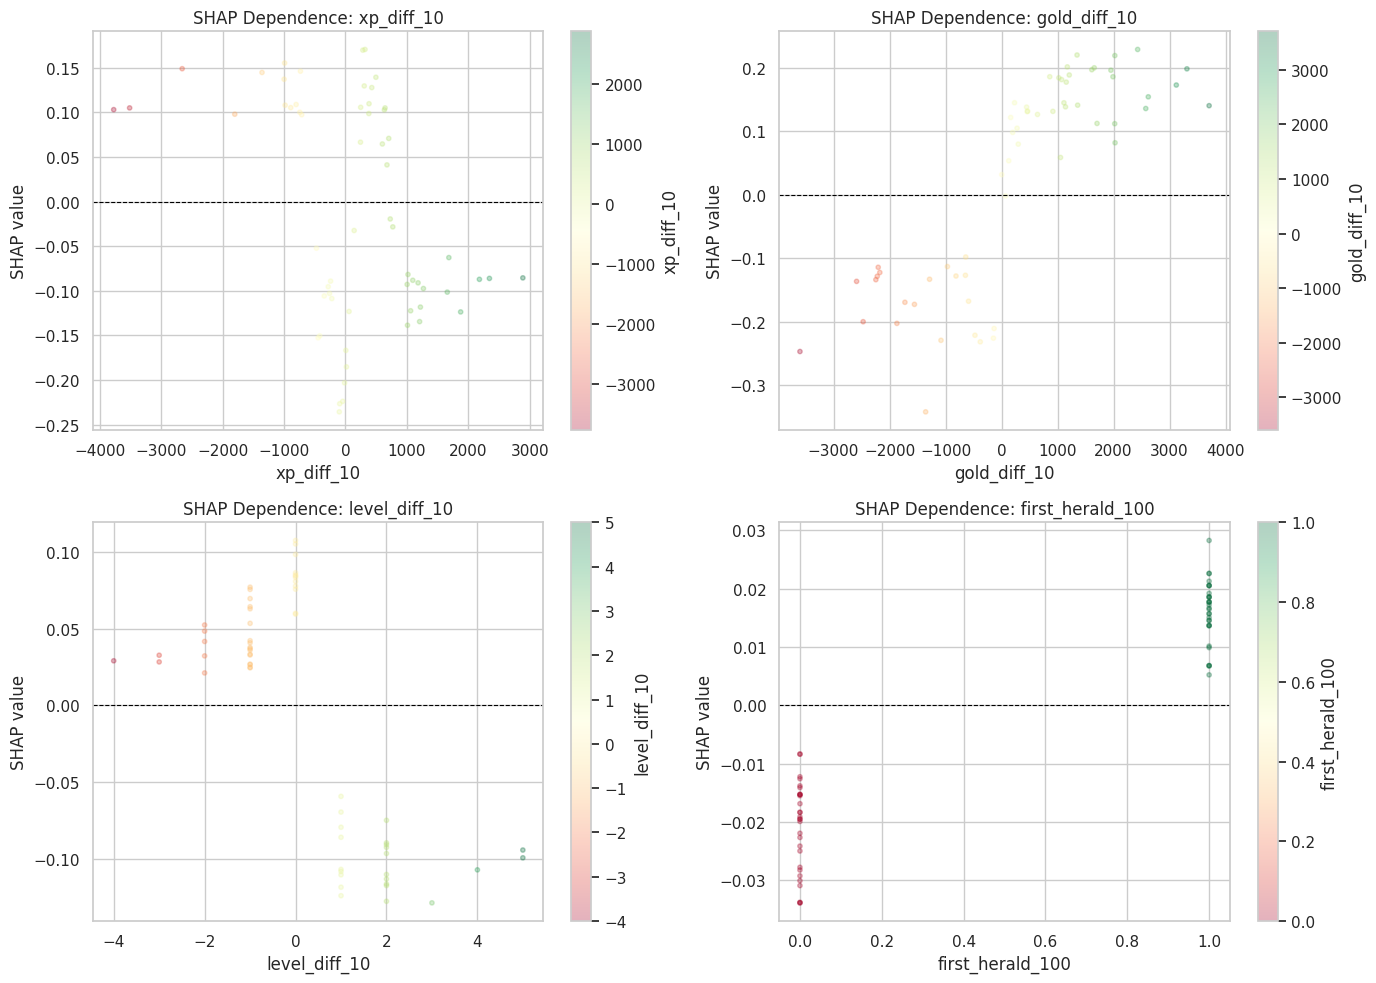

Computing permutation importance (may take ~1 min)...

Top 20 Permutation Importance:
            feature  importance    std
         xp_diff_20      0.2037 0.0403
     dragon_diff_20      0.0346 0.0144
        total_kills      0.0282 0.0163
       kill_diff_20      0.0125 0.0110
      tower_diff_20      0.0117 0.0095
       gold_diff_10      0.0099 0.0045
       total_towers      0.0086 0.0048
          d20_earth      0.0079 0.0038
       kill_diff_10      0.0075 0.0056
       gold_diff_20      0.0054 0.0062
team100_top30_count      0.0047 0.0024
         cs_diff_20      0.0047 0.0116
            d20_air      0.0046 0.0071
    first_blood_100      0.0040 0.0019
  jungle_cs_diff_10      0.0040 0.0072
team200_top30_count      0.0026 0.0010
   first_herald_100      0.0013 0.0007
      level_diff_10      0.0013 0.0025
         cs_diff_10      0.0012 0.0015
   first_dragon_100      0.0012 0.0030


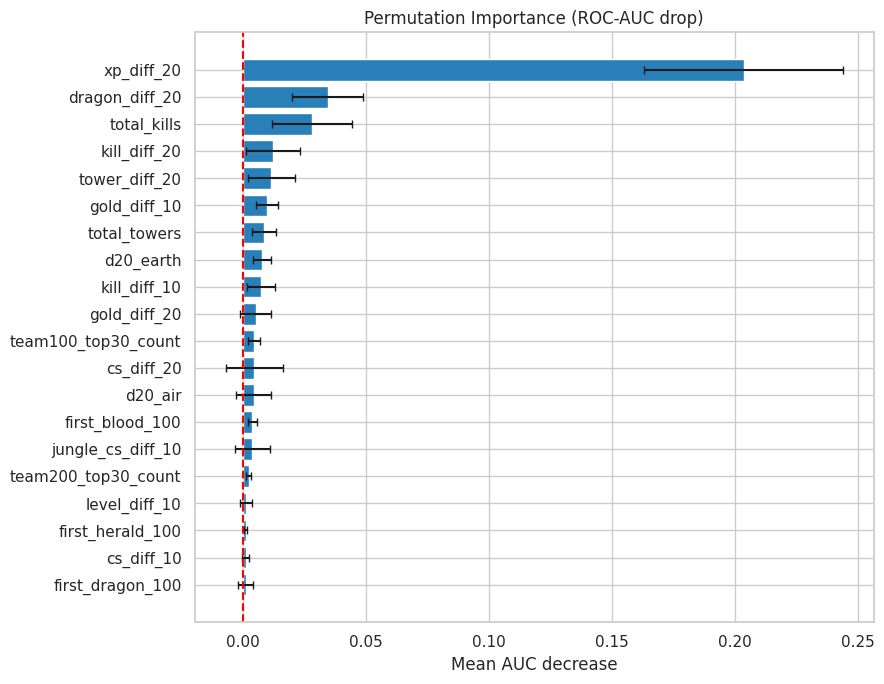

AUDIT 5B: Feature Ablation Study
  Baseline (full model)                         AUC = 0.9007  (reference)

  Drop: xp_diff_20 only                         AUC = 0.8638  (-0.0368)
  Drop: ALL 20-min features                     AUC = 0.6808  (-0.2199)
  Drop: ALL champion flags (P7)                 AUC = 0.9051  (+0.0045)
  Drop: first_herald_100 (P6)                   AUC = 0.9096  (+0.0089)
  Drop: level_diff_10 (P5)                      AUC = 0.9029  (+0.0022)
  Drop: xp_lead_pct_10 (P4)                     AUC = 0.9118  (+0.0112)
  Drop: 20m + champion features                 AUC = 0.6685  (-0.2321)

📊 Interpretasi:
  • Drop besar (>0.01) → fitur tsb penting
  • Drop kecil (<0.005) → fitur redundan / bisa dihapus
  • AUC naik saat drop → fitur menambah noise
Rebuilding champion synergy …

Diagnosis:
  pick_total2 entries : 169
  pair_total2 entries : 4085
  champ_baseline      : 169
  Kolom champ         : ['team100_champs', 'team200_champs']
  Sample parse [team100_champs]: [48, 

In [28]:
print("=" * 65)
print("AUDIT 1A: Data Leakage Check")
print("=" * 65)

FEATURES_10M = [
    "gold_diff_10", "xp_diff_10", "xp_lead_pct_10",
    "cs_diff_10", "jungle_cs_diff_10", "kill_diff_10",
    "tower_diff_10", "dragon_diff_10", "level_diff_10",
    "first_blood_100", "first_dragon_100", "first_tower_100",
    "first_herald_100",
]
FEATURES_20M = [
    "gold_diff_20", "xp_diff_20", "cs_diff_20",
    "kill_diff_20", "tower_diff_20", "dragon_diff_20", "baron_diff_20",
    "total_kills", "total_dragons", "total_barons", "total_towers",
    "herald_100", "herald_200", "d20_air", "d20_fire", "d20_water", "d20_earth",
]
CHAMP_FEATURES = [c for c in match_features.columns
                  if c.startswith("team100_has_") or c.startswith("team200_has_")]
META_FEATURES  = ["team100_top30_count", "team200_top30_count", "meta_pick_diff"]

feat_10m = [c for c in FEATURES_10M + CHAMP_FEATURES + META_FEATURES if c in match_features.columns]
feat_20m = [c for c in FEATURES_10M + FEATURES_20M + CHAMP_FEATURES + META_FEATURES if c in match_features.columns]

current_feats = list(X.columns)
leakage_cols  = [c for c in current_feats if c in FEATURES_20M]

print(f"\nFitur total di model saat ini : {len(current_feats)}")
print(f"Fitur menit-20 yang dipakai   : {len(leakage_cols)}")
if leakage_cols:
    print("  ⚠️  LEAKAGE TERDETEKSI — fitur ini tidak tersedia di menit ke-10:")
    for c in leakage_cols:
        print(f"     • {c}")
    print("\n→ Model FULL bukan 'early game predictor' — ini mid-game predictor.")
    print("→ Audit 1B di bawah memisahkan keduanya.")
else:
    print("  ✅ Tidak ada leakage menit-20 di model.")

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

y_full = match_features["win"]

def train_xgb(X_tr, y_tr, X_te, y_te, label):
    m = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      eval_metric="logloss", random_state=42, verbosity=0)
    m.fit(X_tr, y_tr)
    prob = m.predict_proba(X_te)[:, 1]
    auc  = roc_auc_score(y_te, prob)
    print(f"  {label:<35} ROC-AUC = {auc:.4f}")
    return m, auc

X_10 = match_features[feat_10m].fillna(0)
X_20 = match_features[feat_20m].fillna(0)

X10_tr, X10_te, y10_tr, y10_te = train_test_split(X_10, y_full, test_size=0.2, random_state=42, stratify=y_full)
X20_tr, X20_te, y20_tr, y20_te = train_test_split(X_20, y_full, test_size=0.2, random_state=42, stratify=y_full)

print("\nAUDIT 1B: Early Game (10m) vs Mid Game (20m) vs Full Model")
print("-" * 60)
model_10m, auc_10m = train_xgb(X10_tr, y10_tr, X10_te, y10_te, "Early Game Model (≤10 min)")
model_20m, auc_20m = train_xgb(X20_tr, y20_tr, X20_te, y20_te, "Mid Game Model  (≤20 min)")

full_prob = best_model.predict_proba(X_test)[:, 1]
auc_full  = roc_auc_score(y_test, full_prob)
print(f"  {'Full Model (all features)':<35} ROC-AUC = {auc_full:.4f}")

print("\n" + "=" * 60)
print(f"AUC Gain 10m→20m : +{auc_20m - auc_10m:.4f}")
print(f"AUC Gain 20m→Full: +{auc_full - auc_20m:.4f}")
if auc_20m - auc_10m > 0.03:
    print("\n⚠️  GAP BESAR: fitur menit-20 memberikan info signifikan.")
    print("   → Gunakan model_10m untuk 'early game prediction' di portofolio.")
else:
    print("\n✅ Gap kecil: early game features sudah cukup prediktif.")

print("=" * 65)
print("AUDIT 2A: First Tower Win Rate = NaN — Diagnosis")
print("=" * 65)

print("\n1. Distribusi first_tower_100:")
print(match_features["first_tower_100"].value_counts(dropna=False))

valid_ft = match_features[match_features["first_tower_100"].isin([0, 1])]
nan_ft   = match_features[~match_features["first_tower_100"].isin([0, 1])]
print(f"\n   Valid (0/1): {len(valid_ft):,} matches")
print(f"   NaN/lainnya: {len(nan_ft):,} matches")

if "events_df" in dir():
    bk = events_df[events_df["type"] == "BUILDING_KILL"]
    print(f"\n2. BUILDING_KILL events total: {len(bk):,}")
    print("   buildingType dist:")
    print(bk["buildingType"].value_counts(dropna=False).to_string())
    print("\n   towerType dist:")
    if "towerType" in bk.columns:
        print(bk["towerType"].value_counts(dropna=False).to_string())
    print("\n   killerTeamId dist:")
    print(bk["killerTeamId"].value_counts(dropna=False).head(8).to_string())

    matches_with_tower = bk["matchId"].nunique()
    total_matches      = events_df["matchId"].nunique()
    print(f"\n3. Matches dengan BUILDING_KILL: {matches_with_tower:,} / {total_matches:,}")
    print(f"   Coverage: {matches_with_tower/total_matches:.1%}")

    print("\n4. Sample BUILDING_KILL events:")
    print(bk[["matchId","timestamp","buildingType","towerType","killerTeamId","killerId"]].head(10).to_string(index=False))
else:
    print("\n⚠️  events_df tidak ada di scope — jalankan Part 1 lebih dulu.")
    print(f"   Dari match_features, first_tower_100 non-zero: {(match_features['first_tower_100'] != 0).sum()}")

print("AUDIT 2B: first_tower_100 — status check")

match_features["first_tower_100_fixed"] = match_features["first_tower_100"]

valid = match_features["first_tower_100_fixed"].notna().sum()
print(f"  Matches dengan first_tower valid: {valid:,} / {len(match_features):,}")
print(f"  Coverage: {valid/len(match_features):.1%}")

if valid > 0:
    print("\n  Win rate first_tower:")
    wr = match_features.groupby("first_tower_100_fixed")["win"].agg(["mean", "count"])
    print(wr.to_string())
    print("\n✅ first_tower_100 sudah valid (dihitung via teamId pada BUILDING_KILL, Cell 12).")
else:
    print("\n⚠️  first_tower_100 masih NaN — pastikan Cell 12 (teamId fix) sudah dijalankan")
    print("   sebelum feature engineering Part 1 (perlu re-run Part 1 + re-save parquet).")

print("=" * 65)
print("AUDIT 3: Feature Quality Report")
print("=" * 65)

feat_cols = list(X.columns)
Xq = match_features[feat_cols].copy()

print("\n3A: Missing Value Report")
miss = Xq.isna().mean().sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
if len(miss_nonzero):
    print(miss_nonzero.to_string())
else:
    print("  ✅ Tidak ada missing values (setelah fillna(0))")

print("\n3B: Constant / Near-Constant Features (std < 0.01)")
stds = Xq.std()
const_feats = stds[stds < 0.01]
if len(const_feats):
    print(f"  ⚠️  {len(const_feats)} fitur hampir konstan:")
    print(const_feats.to_string())
else:
    print("  ✅ Tidak ada constant features")

print("\n3C: Highly Correlated Features (|r| > 0.95)")
corr_matrix = Xq.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.95]
high_corr.sort(key=lambda x: x[2], reverse=True)
if high_corr:
    print(f"  ⚠️  {len(high_corr)} pasang fitur highly correlated:")
    for a, b, r in high_corr[:15]:
        print(f"     {a:<35} ↔ {b:<35}  r={r:.3f}")
else:
    print("  ✅ Tidak ada pasang fitur dengan r > 0.95")

print("\n3D: Target Leakage Suspicion (|corr dengan win| > 0.7)")
target_corr = Xq.corrwith(match_features["win"]).abs().sort_values(ascending=False)
suspicious  = target_corr[target_corr > 0.7]
if len(suspicious):
    print(f"  ⚠️  {len(suspicious)} fitur sangat berkorelasi dengan target:")
    print(suspicious.to_string())
    print("  → Periksa apakah fitur ini hanya bisa diketahui setelah game berakhir.")
else:
    print("  ✅ Tidak ada fitur dengan suspisi target leakage (>0.7)")

print("\nTop 10 fitur berdasarkan |corr| dengan win:")
print(target_corr.head(10).to_string())

import shap
import matplotlib.pyplot as plt

print("Computing SHAP values (sample=500)...")
explainer_a = shap.TreeExplainer(best_model)
samp        = X_test.sample(min(500, len(X_test)), random_state=42)
sv          = explainer_a.shap_values(samp)

shap_df   = pd.DataFrame(sv, columns=samp.columns)
shap_mean = shap_df.abs().mean().sort_values(ascending=False)

print("\n4A: Top 20 SHAP Features (mean |SHAP value|):")
print(shap_mean.head(20).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
shap_mean.head(20).sort_values().plot(kind="barh", ax=ax, color="#e74c3c")
ax.set_title("Top 20 SHAP Features — Mean |SHAP Value|")
ax.set_xlabel("Mean |SHAP Value|")
plt.tight_layout(); plt.show()

shap.summary_plot(sv, samp, max_display=20, show=True, plot_type="dot")

dep_features = ["xp_diff_10", "gold_diff_10", "level_diff_10", "first_herald_100"]
dep_features = [f for f in dep_features if f in samp.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feat in enumerate(dep_features):
    feat_idx = list(samp.columns).index(feat)
    feat_sv  = sv[:, feat_idx]
    feat_val = samp[feat].values

    ax = axes[i]
    scatter = ax.scatter(feat_val, feat_sv, alpha=0.3, s=10, c=feat_val, cmap="RdYlGn")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(feat)
    ax.set_ylabel("SHAP value")
    ax.set_title(f"SHAP Dependence: {feat}")
    plt.colorbar(scatter, ax=ax, label=feat)

plt.tight_layout(); plt.show()

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

print("Computing permutation importance (may take ~1 min)...")
perm = permutation_importance(best_model, X_test, y_test,
                               n_repeats=10, random_state=42, n_jobs=-1,
                               scoring="roc_auc")

perm_df = pd.DataFrame({
    "feature":    X_test.columns,
    "importance": perm.importances_mean,
    "std":        perm.importances_std,
}).sort_values("importance", ascending=False)

print("\nTop 20 Permutation Importance:")
print(perm_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
top20_perm = perm_df.head(20).sort_values("importance")
ax.barh(top20_perm["feature"], top20_perm["importance"],
        xerr=top20_perm["std"], color="#2980b9", capsize=3)
ax.axvline(0, color="red", linestyle="--")
ax.set_title("Permutation Importance (ROC-AUC drop)")
ax.set_xlabel("Mean AUC decrease")
plt.tight_layout(); plt.show()

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def ablation_auc(drop_cols, label):
    keep = [c for c in X.columns if c not in drop_cols]
    if not keep:
        return None
    Xa = X[keep].fillna(0)
    y_clean = match_features["win"].fillna(0).astype(int)
    Xtr, Xte, ytr, yte = train_test_split(Xa, y_clean, test_size=0.2,
                                           random_state=42, stratify=y_clean)
    m = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      eval_metric="logloss", random_state=42, verbosity=0)
    m.fit(Xtr, ytr)
    auc = roc_auc_score(yte, m.predict_proba(Xte)[:, 1])
    delta = auc - auc_full
    sign  = "+" if delta >= 0 else ""
    print(f"  {label:<45} AUC = {auc:.4f}  ({sign}{delta:.4f})")
    return auc

print("=" * 65)
print("AUDIT 5B: Feature Ablation Study")
print("=" * 65)
print(f"  {'Baseline (full model)':<45} AUC = {auc_full:.4f}  (reference)")
print()

feat_20m_present = [c for c in FEATURES_20M if c in X.columns]
champ_present    = [c for c in X.columns if c.startswith("team100_has_") or c.startswith("team200_has_")]
xp20_col         = ["xp_diff_20"] if "xp_diff_20" in X.columns else []

ablation_auc(xp20_col,            "Drop: xp_diff_20 only")
ablation_auc(feat_20m_present,    "Drop: ALL 20-min features")
ablation_auc(champ_present,       "Drop: ALL champion flags (P7)")
ablation_auc(["first_herald_100"],"Drop: first_herald_100 (P6)")
ablation_auc(["level_diff_10"],   "Drop: level_diff_10 (P5)")
ablation_auc(["xp_lead_pct_10"],  "Drop: xp_lead_pct_10 (P4)")
ablation_auc(feat_20m_present + champ_present, "Drop: 20m + champion features")

print("\n📊 Interpretasi:")
print("  • Drop besar (>0.01) → fitur tsb penting")
print("  • Drop kecil (<0.005) → fitur redundan / bisa dihapus")
print("  • AUC naik saat drop → fitur menambah noise")

import ast
from collections import defaultdict
from itertools import combinations

print("Rebuilding champion synergy …")

def parse_champs(val):
    if isinstance(val, list):
        return [int(float(c)) for c in val if pd.notna(c)]
    try:
        return [int(float(c)) for c in ast.literal_eval(str(val)) if pd.notna(c)]
    except:
        return []

pair_wins2  = defaultdict(int)
pair_total2 = defaultdict(int)
pick_wins2  = defaultdict(int)
pick_total2 = defaultdict(int)

for _, row in match_features.iterrows():
    win_val = int(row["win"])
    t100    = parse_champs(row["team100_champs"])
    t200    = parse_champs(row["team200_champs"])

    for c in t100:
        pick_total2[c] += 1
        pick_wins2[c]  += win_val
    for c in t200:
        pick_total2[c] += 1
        pick_wins2[c]  += (1 - win_val)

    for champs, tw in [(t100, win_val), (t200, 1 - win_val)]:
        for a, b in combinations(sorted(champs), 2):
            pair_total2[(a, b)] += 1
            pair_wins2[(a, b)]  += tw

champ_baseline = {c: pick_wins2[c] / pick_total2[c] for c in pick_total2 if pick_total2[c] > 0}

print(f"\nDiagnosis:")
print(f"  pick_total2 entries : {len(pick_total2)}")
print(f"  pair_total2 entries : {len(pair_total2)}")
print(f"  champ_baseline      : {len(champ_baseline)}")

champ_cols = [c for c in match_features.columns if "champ" in c.lower()]
print(f"  Kolom champ         : {champ_cols}")

sample_row = match_features.iloc[0]
for col in champ_cols:
    parsed = parse_champs(sample_row[col])
    print(f"  Sample parse [{col}]: {parsed}")

synergy_records = []
for (a, b), total in pair_total2.items():
    if total < 5:
        continue
    pair_wr       = pair_wins2[(a, b)] / total
    baseline_avg  = (champ_baseline.get(a, 0.5) + champ_baseline.get(b, 0.5)) / 2
    synergy_score = pair_wr - baseline_avg
    synergy_records.append({
        "champ_a": a, "champ_b": b, "co_picks": total,
        "pair_winrate": pair_wr, "baseline_wr": baseline_avg,
        "synergy_score": synergy_score,
    })

print(f"\n  synergy_records (min 5 co-picks): {len(synergy_records)}")

if len(synergy_records) == 0:
    print("  ⚠️  Records kosong — mencoba min co-picks = 1 ...")
    for (a, b), total in pair_total2.items():
        pair_wr       = pair_wins2[(a, b)] / total
        baseline_avg  = (champ_baseline.get(a, 0.5) + champ_baseline.get(b, 0.5)) / 2
        synergy_score = pair_wr - baseline_avg
        synergy_records.append({
            "champ_a": a, "champ_b": b, "co_picks": total,
            "pair_winrate": pair_wr, "baseline_wr": baseline_avg,
            "synergy_score": synergy_score,
        })
    print(f"  Records dengan min 1: {len(synergy_records)}")

if len(synergy_records) == 0:
    print("\n  ❌ pair_total2 kosong — kolom team100_champs / team200_champs tidak ter-parse.")
    print("  → Cek nama kolom dan format datanya di atas.")
    synergy_df = pd.DataFrame(columns=["champ_a","champ_b","co_picks","pair_winrate","baseline_wr","synergy_score"])
else:
    synergy_df = pd.DataFrame(synergy_records).sort_values("synergy_score", ascending=False).reset_index(drop=True)
    print(f"\n✅ synergy_df: {len(synergy_df):,} pairs")
    print(synergy_df.head(5).to_string(index=False))

cs_path = os.path.join(OUTPUT_DIR, "champion_synergy.parquet")
cp_path = os.path.join(OUTPUT_DIR, "champion_picks.parquet")

synergy_df.to_parquet(cs_path, index=False)
champ_stats.to_parquet(cp_path, index=False)

print("✅ Synergy parquets saved:")
for p in [cs_path, cp_path]:
    size_kb = os.path.getsize(p) / 1024
    print(f"   {p}  ({size_kb:.0f} KB)")

synergy_df["name_a"] = synergy_df["champ_a"].apply(id_to_name)
synergy_df["name_b"] = synergy_df["champ_b"].apply(id_to_name)
synergy_df["pair"]   = synergy_df["name_a"] + " + " + synergy_df["name_b"]

print("=== TOP 20 PAIRS — SYNERGY SCORE ===")
print(synergy_df.head(20)[["pair","co_picks","pair_winrate","baseline_wr","synergy_score"]].to_string(index=False))

print("\n=== TOP 20 PAIRS — WIN RATE (min 10 co-picks) ===")
top_wr_pairs = synergy_df[synergy_df["co_picks"] >= 10].sort_values("pair_winrate", ascending=False)
print(top_wr_pairs.head(20)[["pair","co_picks","pair_winrate","synergy_score"]].to_string(index=False))

print("\n=== TOP 20 PAIRS — PICK RATE ===")
top_pick_pairs = synergy_df.sort_values("co_picks", ascending=False)
print(top_pick_pairs.head(20)[["pair","co_picks","pair_winrate","synergy_score"]].to_string(index=False))

synergy_df.to_csv("champion_synergy_audit.csv", index=False)
print("\n✅ champion_synergy_audit.csv saved.")

import plotly.graph_objects as go
import networkx as nx

MIN_PICKS   = 8
MIN_SYNERGY = 0.02

G = nx.Graph()
for _, row in synergy_df[(synergy_df["co_picks"] >= MIN_PICKS) &
                          (synergy_df["synergy_score"] >= MIN_SYNERGY)].iterrows():
    a, b = str(int(row["champ_a"])), str(int(row["champ_b"]))
    G.add_edge(a, b, weight=float(row["co_picks"]), synergy=float(row["synergy_score"]))

print(f"Network: {len(G.nodes())} champions, {len(G.edges())} edges")

if len(G.nodes()) < 2:
    print("⚠️  Kurang data. Turunkan MIN_PICKS atau MIN_SYNERGY.")
else:
    pos = nx.spring_layout(G, seed=42, k=1.5)

    edge_traces = []
    for u, v, data in G.edges(data=True):
        x0, y0 = pos[u]; x1, y1 = pos[v]
        syn = max(0.0, min(1.0, data["synergy"] * 5))
        r   = int(255 * (1 - syn))
        g   = int(200 * syn)
        edge_traces.append(go.Scatter(
            x=[x0, x1, None], y=[y0, y1, None], mode="lines",
            line=dict(width=max(1, data["weight"] / 5), color=f"rgba({r},{g},100,0.6)"),
            hoverinfo="none",
        ))

    node_x, node_y, node_text, node_size = [], [], [], []
    for node in G.nodes():
        x, y = pos[node]
        node_x.append(x); node_y.append(y)
        degree = G.degree(node)
        wr     = champ_baseline.get(int(node), 0.5)
        node_text.append(f"Champ {node}<br>WR: {wr:.1%}<br>Connections: {degree}")
        node_size.append(8 + degree * 3)

    node_trace = go.Scatter(
        x=node_x, y=node_y, mode="markers+text",
        text=list(G.nodes()), textposition="top center",
        hovertext=node_text, hoverinfo="text",
        marker=dict(size=node_size, color="#3498db", line=dict(width=1, color="white")),
    )

    fig = go.Figure(
        data=edge_traces + [node_trace],
        layout=go.Layout(
            title=f"Champion Synergy Network (synergy ≥ {MIN_SYNERGY}, co-picks ≥ {MIN_PICKS})",
            showlegend=False, hovermode="closest",
            margin=dict(b=20, l=5, r=5, t=50),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            height=600,
        )
    )
    fig.show()


## 🔁 Patch Robustness — AUC Comparison

*(this needs the trained full model `best_model`/`X`/`X_test`/`y_test` from the Leakage & Feature Audit above)*

In [29]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

print("=" * 60)
print("PATCH ROBUSTNESS — AUC COMPARISON")
print("=" * 60)

if "patch" not in match_features.columns:
    match_features["patch"] = (
        match_features["gameVersion"]
        .astype(str)
        .str.extract(r"^(\d+\.\d+)", expand=False)
        .fillna("unknown")
    )

patch_counts   = match_features["patch"].value_counts()
dominant_patch = patch_counts.idxmax()
n_patches      = patch_counts.shape[0]

dominant_idx = match_features.index[match_features["patch"] == dominant_patch]

if len(dominant_idx) < 30:
    top2 = patch_counts.head(2).index.tolist()
    dominant_idx   = match_features.index[match_features["patch"].isin(top2)]
    dominant_patch = "+".join(top2)
    print(f"⚠️  Terlalu sedikit matches di 1 patch — gabungkan top-2: {top2}")

other_idx = match_features.index.difference(dominant_idx)

print(f"Dominant patch : {dominant_patch}  ({len(dominant_idx):,} matches)")
print(f"Other patches  : {len(other_idx):,} matches")

if len(dominant_idx) < 40:
    print("\n⚠️  Tidak cukup data untuk train/test split di dominant patch.")
    print("   Skipping AUC comparison.")
else:
    X_dom = X.loc[dominant_idx]
    y_dom = match_features.loc[dominant_idx, "win"]

    X_dom_tr, X_dom_te, y_dom_tr, y_dom_te = train_test_split(
        X_dom, y_dom, test_size=0.20, random_state=42, stratify=y_dom
    )
    model_dom = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=42, verbosity=0
    )
    model_dom.fit(X_dom_tr, y_dom_tr)
    auc_dom = roc_auc_score(y_dom_te, model_dom.predict_proba(X_dom_te)[:, 1])

    print(f"\n{'Model':<45} {'AUC':>7}  {'N test':>8}")
    print("-" * 63)
    print(f"  {'Full dataset (all patches)':<43} {auc_full:.4f}  {len(y_test):>8}")
    print(f"  {'Dominant patch only (' + dominant_patch + ')':<43} {auc_dom:.4f}  {len(y_dom_te):>8}")

    delta = auc_dom - auc_full
    sign  = "+" if delta >= 0 else ""
    print(f"\n  Delta (dominant - full) : {sign}{delta:.4f}")

    if abs(delta) < 0.015:
        print("  ✅ Model ROBUST terhadap patch drift — AUC stabil.")
        print("     Temuan berlaku di seluruh patch dalam dataset ini.")
    elif delta > 0.015:
        print("  📈 Model lebih akurat di dominant patch — data lebih homogen.")
        print("     Untuk deployment, pertimbangkan patch-specific model.")
    else:
        print("  📉 Model sedikit kurang akurat di dominant patch saja.")
        print("     Kemungkinan patch lain memiliki pola yang membantu generalisasi.")

    globals()["auc_dominant_patch"] = auc_dom
    globals()["dominant_patch_name"] = dominant_patch

    if len(other_idx) >= 20:
        X_other = X.loc[other_idx]
        y_other = match_features.loc[other_idx, "win"]
        auc_cross = roc_auc_score(y_other, model_dom.predict_proba(X_other)[:, 1])
        print(f"\n  Cross-patch AUC (train={dominant_patch}, test=others): {auc_cross:.4f}")
        if auc_cross > 0.60:
            print("  ✅ Model generalises reasonably across patches.")
        else:
            print("  ⚠️  Cross-patch AUC rendah — patch drift signifikan.")

print("\n✅ Patch robustness analysis selesai.")


PATCH ROBUSTNESS — AUC COMPARISON
Dominant patch : 15.7  (214 matches)
Other patches  : 86 matches

Model                                             AUC    N test
---------------------------------------------------------------
  Full dataset (all patches)                  0.9007        60
  Dominant patch only (15.7)                  0.9189        43

  Delta (dominant - full) : +0.0182
  📈 Model lebih akurat di dominant patch — data lebih homogen.
     Untuk deployment, pertimbangkan patch-specific model.

  Cross-patch AUC (train=15.7, test=others): 0.9346
  ✅ Model generalises reasonably across patches.

✅ Patch robustness analysis selesai.


## 🧩 Player Archetype Clustering

ℹ️  kill_pm/death_pm/assist_pm aliased dari kills/deaths/kda_proxy


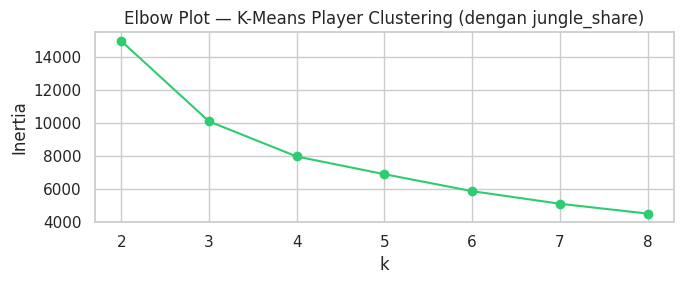


Cluster profiles (raw means):
         gold_pm    xp_pm  cs_pm  jungle_cs_pm  jungle_share  kills  deaths  kda_proxy
cluster                                                                               
0       370.0390 462.0730 6.5550        0.1900        0.0150 0.0000  7.6700     0.0710
1       421.9290 511.6850 6.9150        5.9600        0.4650 0.0000  4.8440     0.1630
2       280.3190 359.0660 1.3250        0.0300        0.0030 0.0000  5.1180     0.1490
3       442.7130 550.1600 7.7520        0.1990        0.0160 0.0000  3.9720     0.1480
4       444.5440 534.3220 7.7030        0.1740        0.0130 0.0000  0.6650     0.5000


In [30]:
CLUSTER_FEATS = [
    "gold_pm", "xp_pm", "cs_pm", "jungle_cs_pm",
    "jungle_share",
    "kills", "deaths", "kda_proxy"
]

pf_clean = player_features[[c for c in CLUSTER_FEATS + ["matchId","participantSlot","won"]
                             if c in player_features.columns]].dropna()
pf_clean = pf_clean[pf_clean["gold_pm"] > 0].copy()

if "kills" in pf_clean.columns and "kill_pm" not in pf_clean.columns:
    pf_clean["kill_pm"]   = pf_clean["kills"]
    pf_clean["death_pm"]  = pf_clean["deaths"]
    if "kda_proxy" in pf_clean.columns:
        pf_clean["assist_pm"] = pf_clean["kda_proxy"] * pf_clean["deaths"] - pf_clean["kills"]
        pf_clean["assist_pm"] = pf_clean["assist_pm"].clip(lower=0)
    print("ℹ️  kill_pm/death_pm/assist_pm aliased dari kills/deaths/kda_proxy")



scaler_cl = StandardScaler()
X_cluster = scaler_cl.fit_transform(pf_clean[CLUSTER_FEATS])

inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    inertias.append(km.fit(X_cluster).inertia_)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(list(K_range), inertias, "o-", color="#2ecc71")
ax.set_title("Elbow Plot — K-Means Player Clustering (dengan jungle_share)")
ax.set_xlabel("k"); ax.set_ylabel("Inertia")
plt.tight_layout(); plt.show()

K_BEST = 5
kmeans = KMeans(n_clusters=K_BEST, random_state=RANDOM_STATE, n_init=10)
pf_clean["cluster"] = kmeans.fit_predict(X_cluster)

profiles = pf_clean.groupby("cluster")[CLUSTER_FEATS].mean()
print("\nCluster profiles (raw means):")
print(profiles.round(3).to_string())


In [31]:
def label_cluster(row):
    if row["jungle_share"] > profiles["jungle_share"].mean() * 1.5:
        return "Farming Jungler"
    elif row["cs_pm"] < profiles["cs_pm"].mean() * 0.5:
        return "Low-Farm Support"
    elif row["deaths"] < profiles["deaths"].mean() * 0.5 and row["kda_proxy"] > profiles["kda_proxy"].mean() * 1.5:
        return "High-Efficiency Carry"
    elif row["cs_pm"] > profiles["cs_pm"].mean() * 1.1:
        return "Scaling Farmer"
    elif row["deaths"] > profiles["deaths"].mean() * 1.3:
        return "Supportive Engager"
    else:
        return "Objective Controller"

archetype_map = {i: label_cluster(profiles.loc[i]) for i in profiles.index}
pf_clean["archetype"] = pf_clean["cluster"].map(archetype_map)
print("Archetype assignment:", archetype_map)

if UMAP_AVAILABLE:
    reducer = umap.UMAP(random_state=RANDOM_STATE, n_neighbors=30, min_dist=0.1)
    emb = reducer.fit_transform(X_cluster)
    method = "UMAP"
else:
    emb = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_cluster)
    method = "PCA"

vis_df = pd.DataFrame({
    "x": emb[:, 0], "y": emb[:, 1],
    "archetype": pf_clean["archetype"].values,
    "gold_pm":   pf_clean["gold_pm"].values,
    "jungle_share": pf_clean["jungle_share"].values,
})

fig = px.scatter(vis_df, x="x", y="y", color="archetype", opacity=0.4,
    title=f"Player Playstyle Clusters ({method}) — dengan jungle_share (P8)",
    hover_data=["gold_pm","jungle_share"])
fig.show()

cluster_profiles = pf_clean.groupby("archetype")[CLUSTER_FEATS].mean()
fig = go.Figure()
for label, row in cluster_profiles.iterrows():
    vals  = list(row.values) + [row.values[0]]
    theta = CLUSTER_FEATS + [CLUSTER_FEATS[0]]
    fig.add_trace(go.Scatterpolar(r=vals, theta=theta, fill="toself", name=label))
fig.update_layout(title="Cluster Radar Profiles (role-aware)", polar=dict(radialaxis=dict(visible=True)))
fig.show()


Archetype assignment: {0: 'Supportive Engager', 1: 'Farming Jungler', 2: 'Low-Farm Support', 3: 'Scaling Farmer', 4: 'High-Efficiency Carry'}


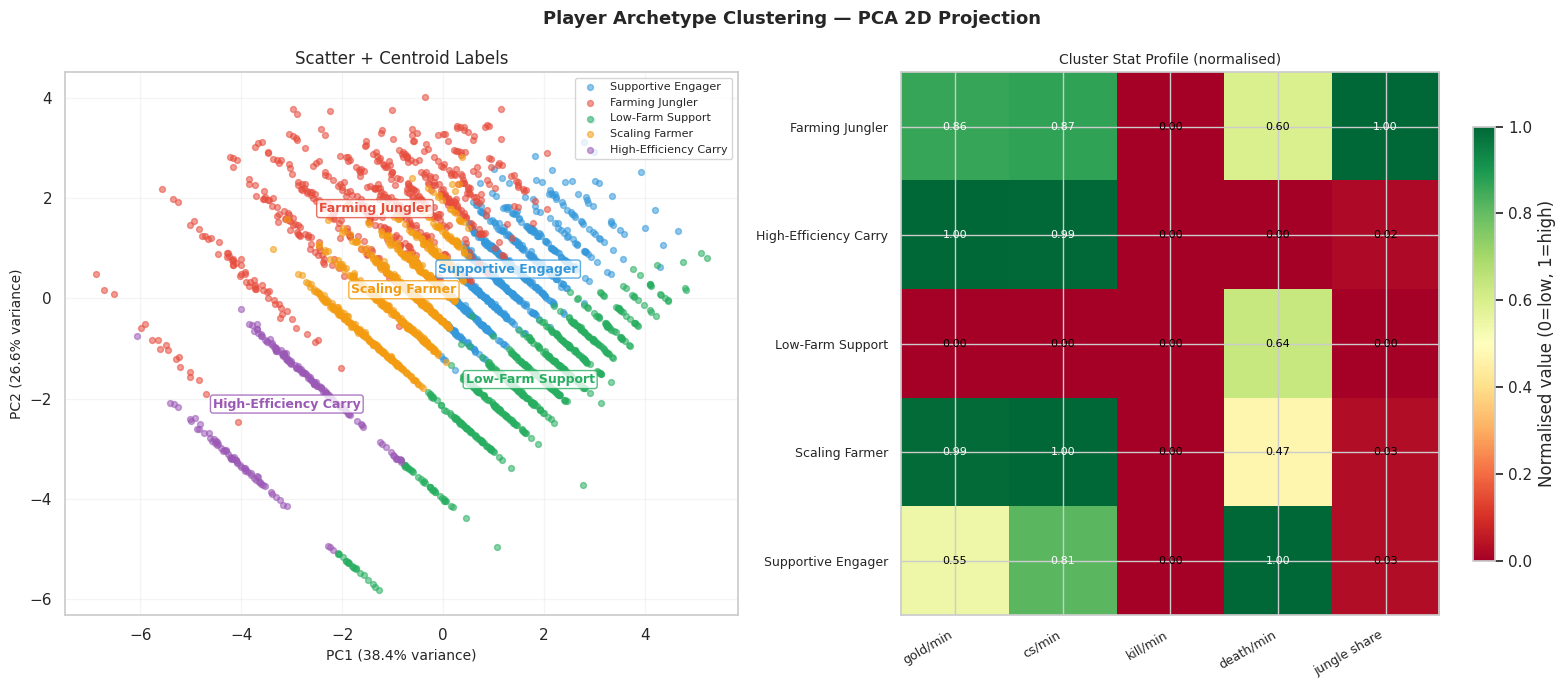

PCA variance explained: PC1=38.4%  PC2=26.6%  total=65.0%

Cluster sizes:
archetype
Farming Jungler          583
High-Efficiency Carry    191
Low-Farm Support         625
Scaling Farmer           853
Supportive Engager       748

✅ PCA enhanced disimpan: viz_pca_cluster_enhanced.png


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

_candidates = [
    "gold_pm", "xp_pm", "cs_pm", "jungle_cs_pm",
    "jungle_share", "kill_pm", "death_pm", "assist_pm",
    "kills", "deaths", "kda_proxy",
]
available = [c for c in _candidates if c in pf_clean.columns]
CLUSTER_FEATS = available
pf_plot   = pf_clean[available + ["cluster"]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pf_plot[available])
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
pf_plot = pf_plot.copy()
pf_plot["pc1"] = coords[:, 0]
pf_plot["pc2"] = coords[:, 1]

var_exp = pca.explained_variance_ratio_ * 100

try:
    label_map = archetype_map
except NameError:
    label_map = {i: f"Cluster {i}" for i in pf_plot["cluster"].unique()}

pf_plot["archetype"] = pf_plot["cluster"].map(label_map)
clusters = sorted(pf_plot["cluster"].unique())
palette  = ["#3498db", "#e74c3c", "#27ae60", "#f39c12", "#9b59b6", "#1abc9c"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Player Archetype Clustering — PCA 2D Projection",
             fontsize=13, fontweight="bold")

ax = axes[0]
for i, cid in enumerate(clusters):
    mask  = pf_plot["cluster"] == cid
    color = palette[i % len(palette)]
    label = label_map.get(cid, f"Cluster {cid}")
    ax.scatter(pf_plot.loc[mask, "pc1"], pf_plot.loc[mask, "pc2"],
               c=color, s=18, alpha=0.55, label=label)
    cx, cy = pf_plot.loc[mask, "pc1"].mean(), pf_plot.loc[mask, "pc2"].mean()
    ax.annotate(label, (cx, cy), fontsize=9, fontweight="bold",
                ha="center", color=color,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.8))

ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance)", fontsize=10)
ax.set_title("Scatter + Centroid Labels")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.2)

ax2 = axes[1]
stat_cols = [c for c in ["gold_pm", "cs_pm", "kill_pm", "death_pm", "jungle_share"] if c in pf_plot.columns]
cluster_means = pf_plot.groupby("archetype")[stat_cols].mean()
normed = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min() + 1e-9)

im = ax2.imshow(normed.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax2.set_xticks(range(len(stat_cols)))
ax2.set_yticks(range(len(cluster_means)))
ax2.set_xticklabels([c.replace("_pm", "/min").replace("_", " ") for c in stat_cols],
                    rotation=30, ha="right", fontsize=9)
ax2.set_yticklabels(cluster_means.index, fontsize=9)
plt.colorbar(im, ax=ax2, shrink=0.8, label="Normalised value (0=low, 1=high)")

for i in range(len(cluster_means)):
    for j in range(len(stat_cols)):
        ax2.text(j, i, f"{normed.values[i, j]:.2f}",
                 ha="center", va="center", fontsize=8,
                 color="black" if normed.values[i, j] < 0.7 else "white")

ax2.set_title("Cluster Stat Profile (normalised)", fontsize=10)

plt.tight_layout()
plt.savefig("viz_pca_cluster_enhanced.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"PCA variance explained: PC1={var_exp[0]:.1f}%  PC2={var_exp[1]:.1f}%  total={sum(var_exp):.1f}%")
print(f"\nCluster sizes:")
print(pf_plot.groupby("archetype").size().rename("count").to_string())
print("\n✅ PCA enhanced disimpan: viz_pca_cluster_enhanced.png")


CLUSTER_FEATS aktif (11): ['gold_pm', 'xp_pm', 'cs_pm', 'jungle_cs_pm', 'jungle_share', 'kills', 'deaths', 'kda_proxy', 'kill_pm', 'death_pm', 'assist_pm']
Anomalies detected : 30 (1.0%)
Z-score anomalies  : 131 (|z| > 3)


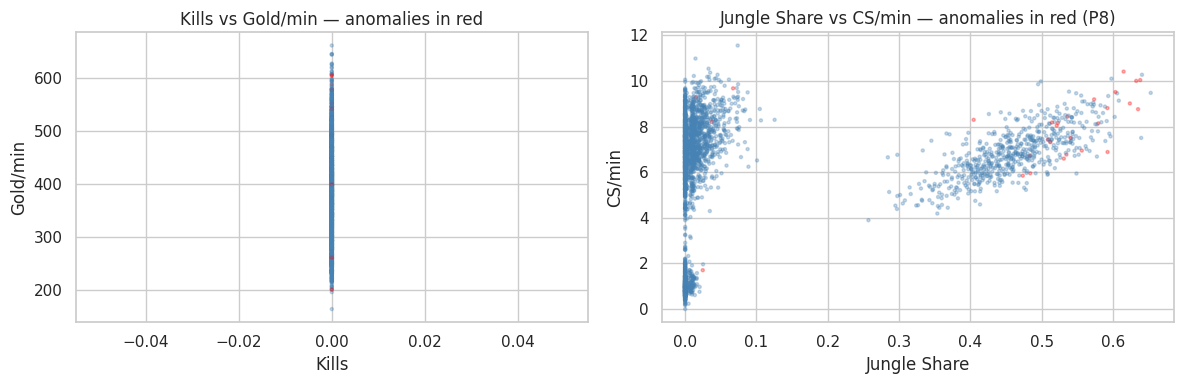


Top 10 anomalous players (by gold/min):
       matchId  participantSlot  gold_pm  kills  deaths             archetype
LA1_1611545730                3 605.9837      0       0 High-Efficiency Carry
LA1_1609858482                2 604.2998      0       1       Farming Jungler
NA1_5269770402                3 588.5940      0       0 High-Efficiency Carry
LA1_1609587779                7 578.1343      0       0 High-Efficiency Carry
LA1_1610635980                2 553.7459      0       0       Farming Jungler
LA1_1612773417                2 552.4448      0       0       Farming Jungler
LA1_1612312655                2 551.9416      0       1       Farming Jungler
NA1_5259397910                2 547.1188      0       0       Farming Jungler
NA1_5265979915                2 546.1322      0       0       Farming Jungler
LA1_1612502397                7 542.3471      0       0       Farming Jungler


In [33]:
_all_cluster_candidates = [
    "gold_pm", "xp_pm", "cs_pm", "jungle_cs_pm", "jungle_share",
    "kills", "deaths", "kda_proxy",
    "kill_pm", "death_pm", "assist_pm",
]
CLUSTER_FEATS = [c for c in _all_cluster_candidates if c in pf_clean.columns]
print(f"CLUSTER_FEATS aktif ({len(CLUSTER_FEATS)}): {CLUSTER_FEATS}")

if "champion" in player_features.columns and "champion" not in pf_clean.columns:
    pf_clean = pf_clean.merge(
        player_features[["matchId", "participantSlot", "champion"]],
        on=["matchId", "participantSlot"],
        how="left"
    )

iso = IsolationForest(contamination=0.01, random_state=RANDOM_STATE, n_jobs=-1)
pf_clean["outlier_score"] = iso.fit_predict(pf_clean[CLUSTER_FEATS])

outliers = pf_clean[pf_clean["outlier_score"] == -1].copy()
print(f"Anomalies detected : {len(outliers):,} ({len(outliers)/len(pf_clean):.1%})")

z = (pf_clean[CLUSTER_FEATS] - pf_clean[CLUSTER_FEATS].mean()) / pf_clean[CLUSTER_FEATS].std()
z_flags = (z.abs() > 3).any(axis=1)
print(f"Z-score anomalies  : {z_flags.sum():,} (|z| > 3)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = (pf_clean["outlier_score"] == -1).map({True: "red", False: "steelblue"})

axes[0].scatter(pf_clean["kills"], pf_clean["gold_pm"], c=colors, alpha=0.3, s=5)
axes[0].set_title("Kills vs Gold/min — anomalies in red")
axes[0].set_xlabel("Kills"); axes[0].set_ylabel("Gold/min")

axes[1].scatter(pf_clean["jungle_share"], pf_clean["cs_pm"], c=colors, alpha=0.3, s=5)
axes[1].set_title("Jungle Share vs CS/min — anomalies in red (P8)")
axes[1].set_xlabel("Jungle Share"); axes[1].set_ylabel("CS/min")

plt.tight_layout(); plt.show()

print("\nTop 10 anomalous players (by gold/min):")
print(outliers.sort_values("gold_pm", ascending=False)
      [["matchId","participantSlot","gold_pm","kills","deaths","archetype"]].head(10).to_string(index=False))


## 🧮 Cluster Report & Anomaly Detection

*Player archetype cluster summary (sizes, centers, PCA/UMAP) followed by Isolation Forest anomaly analysis.*

7A: Cluster Sizes
  Cluster 0 (Supportive Engager       ): 748 players (24.9%)
  Cluster 1 (Farming Jungler          ): 583 players (19.4%)
  Cluster 2 (Low-Farm Support         ): 625 players (20.8%)
  Cluster 3 (Scaling Farmer           ): 853 players (28.4%)
  Cluster 4 (High-Efficiency Carry    ): 191 players (6.4%)

7B: Cluster Centers (z-score normalized)
                       gold_pm   xp_pm   cs_pm  jungle_cs_pm  jungle_share  kills  deaths  kda_proxy
Supportive Engager     -0.2000 -0.1800  0.2300       -0.4600       -0.4600 0.0000  0.8900    -0.6300
Farming Jungler         0.4200  0.3300  0.3600        1.9800        1.9900 0.0000 -0.0900     0.0600
Low-Farm Support       -1.2700 -1.2400 -1.7300       -0.5300       -0.5300 0.0000  0.0100    -0.0400
Scaling Farmer          0.6700  0.7200  0.6800       -0.4600       -0.4600 0.0000 -0.3900    -0.0500
High-Efficiency Carry   0.6900  0.5600  0.6600       -0.4700       -0.4700 0.0000 -1.5300     2.6200


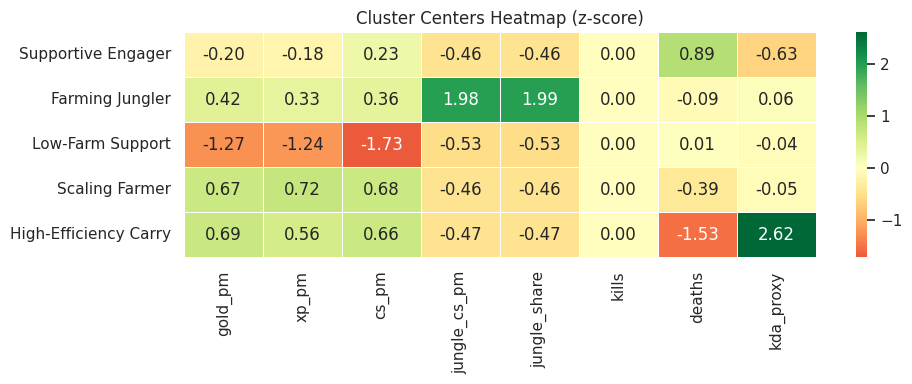

PC1 explains 43.1%, PC2 explains 25.1%
Running UMAP (n_neighbors=30, min_dist=0.1)...


Total anomalies : 30
Normal players  : 2,970

Top 20 Anomalies (sorted by gold_pm):
       matchId  participantSlot             archetype  gold_pm  kills  deaths  jungle_share   cs_pm  kda_proxy                                          reason
LA1_1611545730                3 High-Efficiency Carry 605.9837      0       0        0.0375  8.1989     0.5000                        abnormally high gold/min
LA1_1609858482                2       Farming Jungler 604.2998      0       1        0.6328 10.0022     0.5000 abnormally high gold/min; abnormal jungle share
NA1_5269770402                3 High-Efficiency Carry 588.5940      0       0        0.0148  9.2841     0.5000                           multi-feature extreme
LA1_1609587779                7 High-Efficiency Carry 578.1343      0       0        0.4048  8.2942     0.5000                           multi-feature extreme
LA1_1610635980                2       Farming Jungler 553.7459      0       0        0.5212  8.0385     0.5000           

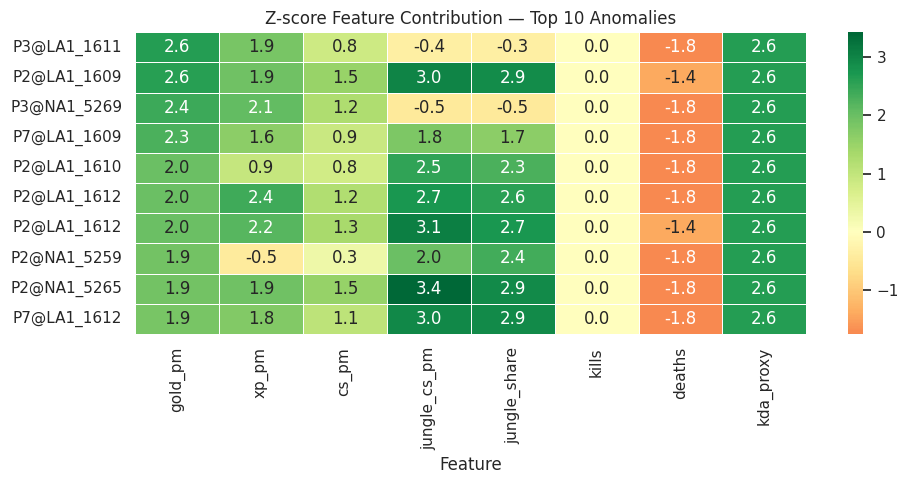

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

assert "cluster" in pf_clean.columns, "Jalankan Cell 21 (KMeans) lebih dulu"

CLUSTER_FEATS_USED = [c for c in [
    "gold_pm","xp_pm","cs_pm","jungle_cs_pm","jungle_share",
    "kills","deaths","kda_proxy"] if c in pf_clean.columns]

print("7A: Cluster Sizes")
sizes = pf_clean["cluster"].value_counts().sort_index()
for cl, sz in sizes.items():
    arch = archetype_map.get(cl, "?")
    print(f"  Cluster {cl} ({arch:<25}): {sz:,} players ({sz/len(pf_clean):.1%})")

print("\n7B: Cluster Centers (z-score normalized)")
sc_vis = StandardScaler()
X_cl   = sc_vis.fit_transform(pf_clean[CLUSTER_FEATS_USED])
centers_norm = pd.DataFrame(X_cl, columns=CLUSTER_FEATS_USED).groupby(pf_clean["cluster"].values).mean()
centers_norm.index = [archetype_map.get(i, f"C{i}") for i in centers_norm.index]
print(centers_norm.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(centers_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Cluster Centers Heatmap (z-score)")
plt.tight_layout(); plt.show()

import plotly.express as px

pca2    = PCA(n_components=2, random_state=42)
emb_pca = pca2.fit_transform(X_cl)

vis_pca = pd.DataFrame({
    "PC1":          emb_pca[:, 0],
    "PC2":          emb_pca[:, 1],
    "Archetype":    pf_clean["archetype"].values,
    "gold_pm":      pf_clean["gold_pm"].values,
    "jungle_share": pf_clean["jungle_share"].values,
    "kda":          pf_clean["kda_proxy"].values,
})
fig = px.scatter(vis_pca, x="PC1", y="PC2", color="Archetype", opacity=0.4,
                 title=f"PCA — Player Archetypes (var explained: {pca2.explained_variance_ratio_.sum():.1%})",
                 hover_data=["gold_pm","jungle_share","kda"])
fig.show()
print(f"PC1 explains {pca2.explained_variance_ratio_[0]:.1%}, PC2 explains {pca2.explained_variance_ratio_[1]:.1%}")

try:
    import umap
    print("Running UMAP (n_neighbors=30, min_dist=0.1)...")
    reducer  = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    emb_umap = reducer.fit_transform(X_cl)

    vis_umap = pd.DataFrame({
        "UMAP1":        emb_umap[:, 0],
        "UMAP2":        emb_umap[:, 1],
        "Archetype":    pf_clean["archetype"].values,
        "gold_pm":      pf_clean["gold_pm"].values,
        "jungle_share": pf_clean["jungle_share"].values,
    })
    fig = px.scatter(vis_umap, x="UMAP1", y="UMAP2", color="Archetype", opacity=0.4,
                     title="UMAP — Player Archetypes", hover_data=["gold_pm","jungle_share"])
    fig.show()
except ImportError:
    print("umap-learn tidak terinstall. Install: !pip install umap-learn")
    print("Menggunakan PCA sudah cukup untuk portofolio.")

assert "outlier_score" in pf_clean.columns, "Jalankan Cell 23 (IsolationForest) lebih dulu"

outliers = pf_clean[pf_clean["outlier_score"] == -1].copy()
normals  = pf_clean[pf_clean["outlier_score"] == 1]

print(f"Total anomalies : {len(outliers):,}")
print(f"Normal players  : {len(normals):,}")

feat_means = pf_clean[CLUSTER_FEATS_USED].mean()
feat_stds  = pf_clean[CLUSTER_FEATS_USED].std().replace(0, 1)

outliers_z = outliers[CLUSTER_FEATS_USED].copy()
for col in CLUSTER_FEATS_USED:
    outliers_z[col] = (outliers[col] - feat_means[col]) / feat_stds[col]

def classify_anomaly(z_row):
    reasons = []
    if z_row.get("gold_pm", 0) < -2.5:    reasons.append("abnormally low gold/min")
    if z_row.get("gold_pm", 0) > 2.5:     reasons.append("abnormally high gold/min")
    if z_row.get("kills", 0) > 2.5:       reasons.append("extremely high kills")
    if z_row.get("deaths", 0) > 2.5:      reasons.append("extremely high deaths")
    if z_row.get("jungle_share", 0) > 2.5:reasons.append("abnormal jungle share")
    if z_row.get("cs_pm", 0) < -2.5:      reasons.append("abnormally low CS/min")
    if z_row.get("xp_pm", 0) < -2.5:      reasons.append("abnormally low XP/min")
    if z_row.get("kda_proxy", 0) > 3.0:   reasons.append("godlike KDA")
    return "; ".join(reasons) if reasons else "multi-feature extreme"

outliers_z["reason"] = outliers_z.apply(classify_anomaly, axis=1)
outliers["reason"]   = outliers_z["reason"].values

display_cols = ["matchId","participantSlot", "champion","archetype","gold_pm","kills","deaths",
                "jungle_share","cs_pm","kda_proxy","reason"]
display_cols = [c for c in display_cols if c in outliers.columns]

print("\nTop 20 Anomalies (sorted by gold_pm):")
print(outliers.sort_values("gold_pm", ascending=False)[display_cols].head(20).to_string(index=False))

print("\n=== Anomaly Reason Distribution ===")
for reason, cnt in outliers["reason"].value_counts().head(10).items():
    print(f"  {cnt:3d}x  {reason}")

print("\n=== Anomaly vs Normal Players (mean) ===")
compare = pd.DataFrame({
    "Normal":  normals[CLUSTER_FEATS_USED].mean(),
    "Anomaly": outliers[CLUSTER_FEATS_USED].mean(),
}).T
print(compare.round(3).to_string())

import matplotlib.pyplot as plt
import seaborn as sns

top_anom   = outliers.sort_values("gold_pm", ascending=False).head(10)
feat_z_top = outliers_z.loc[top_anom.index][CLUSTER_FEATS_USED]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(feat_z_top, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5,
            yticklabels=[f"P{r['participantSlot']}@{r['matchId'][:8]}"
                         for _, r in top_anom.iterrows()])
ax.set_title("Z-score Feature Contribution — Top 10 Anomalies")
ax.set_xlabel("Feature")
plt.tight_layout(); plt.show()


## 🏆 Champion Analysis

Rebuilding champ_stats …
champ_stats: 169 champions


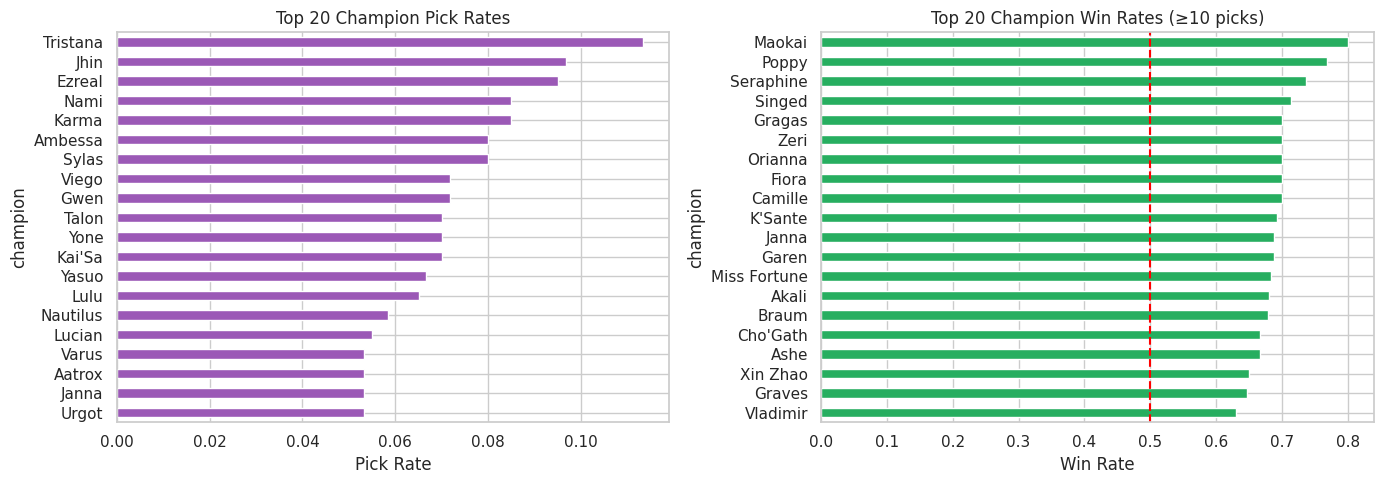


=== P9: META PICK ANALYSIS ===
Mean top30_count per team  : 1.96
                 mean  count
meta_pick_diff              
-2             0.3333     33
-1             0.5857     70
 0             0.5443     79
 1             0.5507     69
 2             0.6061     33
 3             0.5556      9


In [35]:
import ast

print("Rebuilding champ_stats …")
champ_pick = defaultdict(int)
champ_wins = defaultdict(int)
total_teams = 0

for _, row in match_features.iterrows():
    win = int(row["win"])

    def parse_champs(val):
        if isinstance(val, list):
            return [int(float(c)) for c in val if pd.notna(c)]
        try:
            return [int(float(c)) for c in ast.literal_eval(str(val)) if pd.notna(c)]
        except:
            return []

    t100 = parse_champs(row["team100_champs"])
    t200 = parse_champs(row["team200_champs"])

    for c in t100:
        champ_pick[c] += 1
        champ_wins[c] += win
    for c in t200:
        champ_pick[c] += 1
        champ_wins[c] += (1 - win)
    total_teams += 2

if not champ_pick:
    print("⚠️ champ_pick masih kosong — cek isi team100_champs:")
    print(match_features["team100_champs"].head())
else:
    champ_stats = pd.DataFrame([
        {"championId": int(c),
         "picks":     champ_pick[c],
         "wins":      champ_wins[c],
         "pick_rate": champ_pick[c] / total_teams,
         "win_rate":  champ_wins[c] / champ_pick[c]}
        for c in champ_pick
    ]).sort_values("picks", ascending=False).reset_index(drop=True)

    champ_stats["champion"] = champ_stats["championId"].apply(id_to_name)

    print(f"champ_stats: {len(champ_stats)} champions")

    top20_pick = champ_stats.head(20).sort_values("pick_rate")
    top20_wr   = champ_stats[champ_stats["picks"] >= 10].sort_values("win_rate", ascending=False).head(20).sort_values("win_rate")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top20_pick.plot(
        x="champion", y="pick_rate", kind="barh",
        ax=axes[0], color="#9b59b6", legend=False)
    axes[0].set_title("Top 20 Champion Pick Rates")
    axes[0].set_xlabel("Pick Rate")

    top20_wr.plot(
        x="champion", y="win_rate", kind="barh",
        ax=axes[1], color="#27ae60", legend=False)
    axes[1].set_title("Top 20 Champion Win Rates (≥10 picks)")
    axes[1].set_xlabel("Win Rate")
    axes[1].axvline(0.5, color="red", linestyle="--")

    plt.tight_layout(); plt.show()

    print("\n=== P9: META PICK ANALYSIS ===")
    print(f"Mean top30_count per team  : {match_features['team100_top30_count'].mean():.2f}")
    meta_wr = match_features.groupby("meta_pick_diff")["win"].agg(["mean","count"])
    print(meta_wr[meta_wr["count"] >= 5].to_string())


## 🤝 Champion Synergy

*Fixed pipeline — clean champion lists → rebuild pairs → synergy table.*

In [36]:
import re
import pandas as pd
import numpy as np

def clean_champ_list(x):
    if isinstance(x, (list, np.ndarray)):
        cleaned = []
        for v in x:
            nums = re.findall(r"(\d+)", str(v))
            if nums:
                cleaned.append(int(nums[0]))
        return cleaned
    try:
        if pd.isna(x):
            return []
    except (TypeError, ValueError):
        pass
    nums = re.findall(r"(\d+)", str(x))
    return [int(v) for v in nums]


match_features["team100_champs"] = (
    match_features["team100_champs"]
    .apply(clean_champ_list)
)

match_features["team200_champs"] = (
    match_features["team200_champs"]
    .apply(clean_champ_list)
)

print(match_features["team100_champs"].iloc[0])
print(match_features["team200_champs"].iloc[0])


[48, 59, 17, 18, 43]
[157, 120, 518, 236, 34]


In [37]:
from collections import defaultdict
from itertools import combinations
import numpy as np

pair_wins = defaultdict(int)
pair_total = defaultdict(int)

pick_wins = defaultdict(int)
pick_total = defaultdict(int)

for _, row in match_features.iterrows():

    win = int(row["win"])

    team100 = row["team100_champs"]
    team200 = row["team200_champs"]

    for champ in team100:

        pick_total[champ] += 1
        pick_wins[champ] += win

    for champ in team200:

        pick_total[champ] += 1
        pick_wins[champ] += (1 - win)

    for pair in combinations(sorted(team100), 2):

        pair_total[pair] += 1
        pair_wins[pair] += win

    for pair in combinations(sorted(team200), 2):

        pair_total[pair] += 1
        pair_wins[pair] += (1 - win)

print("Unique champions:", len(pick_total))
print("Unique pairs:", len(pair_total))


Unique champions: 169
Unique pairs: 4085


In [38]:
records = []

for (a, b), total in pair_total.items():
    if total < 10:
        continue

    pair_wr = pair_wins[(a, b)] / total

    baseline_wr = (
        pick_wins[a] / pick_total[a]
        +
        pick_wins[b] / pick_total[b]
    ) / 2

    synergy_score = pair_wr - baseline_wr

    weighted_synergy = (
        synergy_score *
        np.log1p(total)
    )

    records.append({
        "champ_a": a,
        "champ_b": b,
        "co_picks": total,
        "pair_winrate": pair_wr,
        "baseline_wr": baseline_wr,
        "synergy_score": synergy_score,
        "weighted_synergy": weighted_synergy
    })

synergy_df = pd.DataFrame(records)

synergy_df = synergy_df.sort_values(
    "weighted_synergy",
    ascending=False
).reset_index(drop=True)

synergy_df["name_a"] = synergy_df["champ_a"].apply(id_to_name)
synergy_df["name_b"] = synergy_df["champ_b"].apply(id_to_name)
synergy_df["pair"]   = synergy_df["name_a"] + " + " + synergy_df["name_b"]

print("Valid synergy pairs:", len(synergy_df))

display(
    synergy_df[["pair","co_picks","pair_winrate","baseline_wr","synergy_score","weighted_synergy"]].head(20)
)


Valid synergy pairs: 2


,pair,co_picks,pair_winrate,baseline_wr,synergy_score,weighted_synergy
0,Karma + Ezreal,10,0.5000,0.4133,0.0867,0.2079
1,Lucian + Nami,13,0.6154,0.5677,0.0476,0.1257


In [39]:
import re, ast
from collections import defaultdict
from itertools import combinations
import numpy as np

def clean_champ_list(x):
    if isinstance(x, (list, np.ndarray)):
        cleaned = []
        for v in x:
            nums = re.findall(r"(\d+)", str(v))
            if nums:
                cleaned.append(int(nums[0]))
        return cleaned
    try:
        if pd.isna(x):
            return []
    except (TypeError, ValueError):
        pass
    nums = re.findall(r"(\d+)", str(x))
    return [int(v) for v in nums]

match_features["team100_champs"] = match_features["team100_champs"].apply(clean_champ_list)
match_features["team200_champs"] = match_features["team200_champs"].apply(clean_champ_list)

pair_wins  = defaultdict(int)
pair_total = defaultdict(int)
pick_wins  = defaultdict(int)
pick_total = defaultdict(int)

for _, row in match_features.iterrows():
    win = int(row["win"])
    t100 = row["team100_champs"]
    t200 = row["team200_champs"]
    for champ in t100:
        pick_total[champ] += 1; pick_wins[champ] += win
    for champ in t200:
        pick_total[champ] += 1; pick_wins[champ] += (1 - win)
    for a, b in combinations(sorted(t100), 2):
        pair_total[(a,b)] += 1; pair_wins[(a,b)] += win
    for a, b in combinations(sorted(t200), 2):
        pair_total[(a,b)] += 1; pair_wins[(a,b)] += (1 - win)

champ_baseline = {c: pick_wins[c]/pick_total[c] for c in pick_total}

champ_stats = pd.DataFrame({
    "championId": list(pick_total.keys()),
    "picks":      [pick_total[c] for c in pick_total],
    "wins":       [pick_wins[c]  for c in pick_total],
}).assign(win_rate=lambda d: d["wins"] / d["picks"]).sort_values("picks", ascending=False)

records = []
for (a, b), total in pair_total.items():
    if total < 5:
        continue
    pair_wr      = pair_wins[(a,b)] / total
    baseline_wr  = (champ_baseline[a] + champ_baseline[b]) / 2
    synergy_score = pair_wr - baseline_wr
    records.append({
        "champ_a": a, "champ_b": b, "co_picks": total,
        "pair_winrate": pair_wr, "baseline_wr": baseline_wr,
        "synergy_score": synergy_score,
        "weighted_synergy": synergy_score * np.log1p(total),
    })

synergy_df = pd.DataFrame(records).sort_values("weighted_synergy", ascending=False).reset_index(drop=True)
synergy_df["name_a"] = synergy_df["champ_a"].apply(id_to_name)
synergy_df["name_b"] = synergy_df["champ_b"].apply(id_to_name)
synergy_df["pair"]   = synergy_df["name_a"] + " + " + synergy_df["name_b"]
champ_stats["champion"] = champ_stats["championId"].apply(id_to_name)
print(f"✅ synergy_df: {len(synergy_df):,} pairs | champ_stats: {len(champ_stats)} champions")
print("   Sample synergy pairs:")
print(synergy_df[["pair","co_picks","pair_winrate","synergy_score"]].head(5).to_string(index=False))


✅ synergy_df: 50 pairs | champ_stats: 169 champions
   Sample synergy pairs:
           pair  co_picks  pair_winrate  synergy_score
    Yone + Gwen         5        1.0000         0.4593
    Kayn + Jhin         5        0.8000         0.3086
Tristana + Lulu         6        0.8333         0.2498
    Jhin + Gwen         5        0.8000         0.2593
   Urgot + Nami         5        0.8000         0.2228


Pairs co-picks ≥ 10 (primary) : 2
Pairs co-picks ≥ 5  (fallback): 50

⚠️  Kurang dari 3 pairs dengan co-picks ≥ 10 untuk dataset ini.
    Menampilkan threshold ≥5 sebagai FALLBACK — angka-angka di bawah
    ini kurang reliable (sample size kecil) dan sebaiknya tidak
    dikutip sebagai klaim winrate yang kuat.

── Top 15 pairs (co-picks ≥ 5, fallback — use with caution) ──
            pair  co_picks  pair_winrate  synergy_score
     Yone + Gwen         5        1.0000         0.4593
 Tristana + Lulu         6        0.8333         0.2498
     Kayn + Jhin         5        0.8000         0.3086
     Jhin + Gwen         5        0.8000         0.2593
    Urgot + Nami         5        0.8000         0.2228
    Garen + Nami         5        0.8000         0.1915
Braum + Aphelios         5        0.8000         0.1750
  Braum + Lucian         5        0.8000         0.1577
Xin Zhao + Akali         5        0.8000         0.1350
Tristana + Sylas         6        0.6667         0.1360
 Tristan

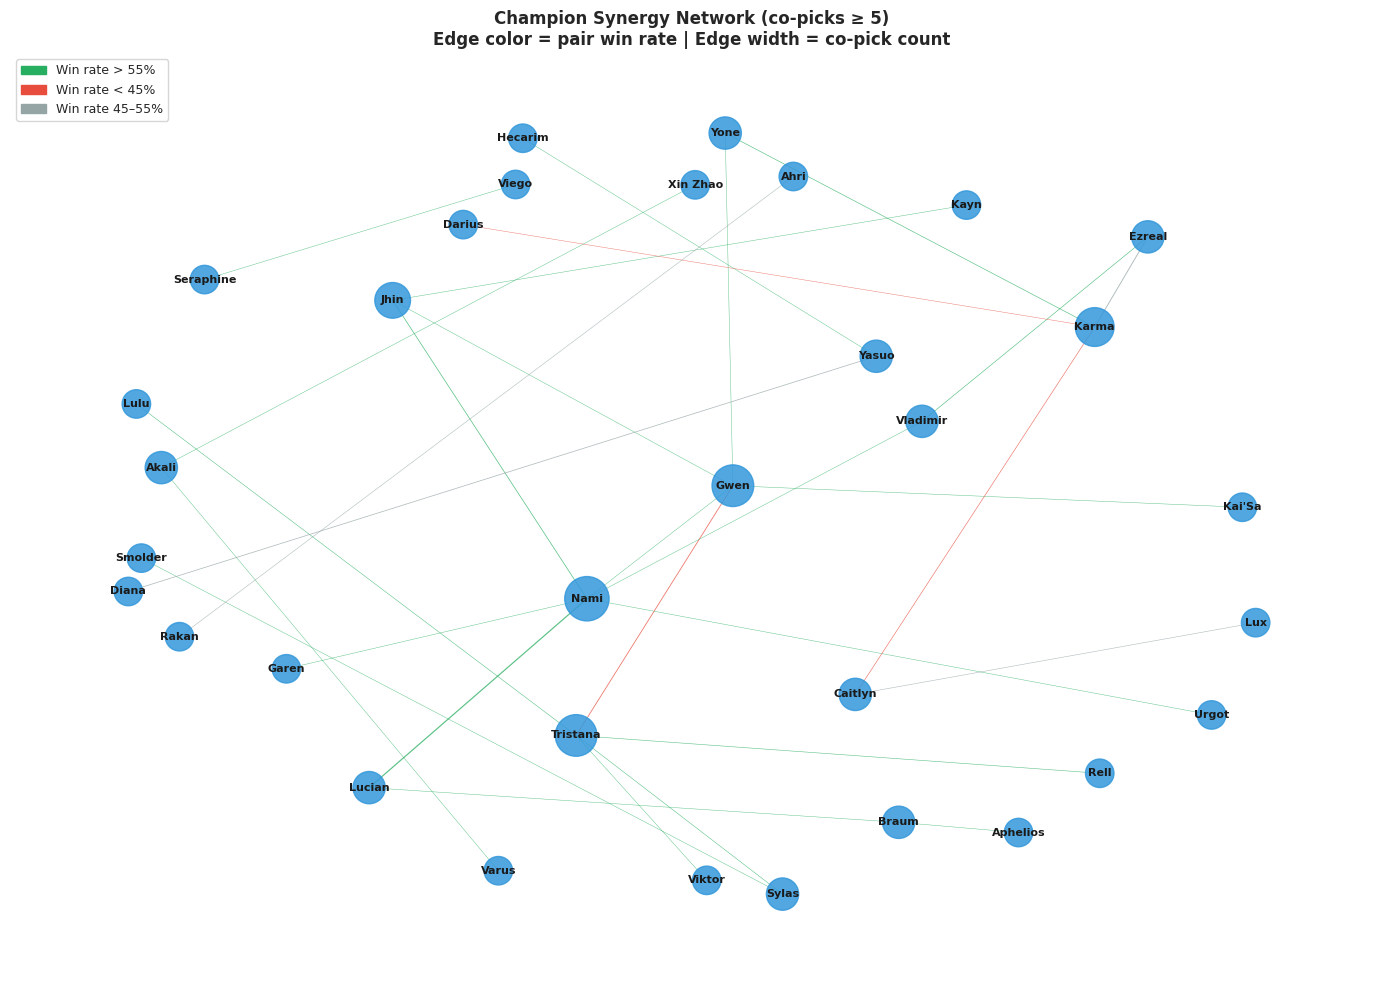

✅ Synergy network disimpan: viz_synergy_network_v2.png (33 champs, 30 pairs)


In [40]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

show_cols = (["pair", "co_picks", "pair_winrate", "synergy_score"]
             if "pair" in synergy_df.columns
             else ["champ_a", "champ_b", "co_picks", "pair_winrate", "synergy_score"])

pairs_10 = synergy_df[synergy_df["co_picks"] >= 10].sort_values("pair_winrate", ascending=False)
pairs_5  = synergy_df[synergy_df["co_picks"] >= 5].sort_values("pair_winrate", ascending=False)

print(f"Pairs co-picks ≥ 10 (primary) : {len(pairs_10):,}")
print(f"Pairs co-picks ≥ 5  (fallback): {len(pairs_5):,}")

if len(pairs_10) >= 3:
    print("\n── Top 15 pairs (co-picks ≥ 10, primary threshold) ──")
    print(pairs_10[show_cols].head(15).to_string(index=False))
else:
    print("\n⚠️  Kurang dari 3 pairs dengan co-picks ≥ 10 untuk dataset ini.")
    print("    Menampilkan threshold ≥5 sebagai FALLBACK — angka-angka di bawah")
    print("    ini kurang reliable (sample size kecil) dan sebaiknya tidak")
    print("    dikutip sebagai klaim winrate yang kuat.")
    print("\n── Top 15 pairs (co-picks ≥ 5, fallback — use with caution) ──")
    print(pairs_5[show_cols].head(15).to_string(index=False))

net_df = pairs_10 if len(pairs_10) >= 5 else pairs_5.head(30)
net_threshold = 10 if len(pairs_10) >= 5 else 5

G = nx.Graph()
if "pair" in net_df.columns and "name_a" in synergy_df.columns:
    for _, row in net_df.iterrows():
        a = row.get("name_a", id_to_name(row.get("champ_a", "?")))
        b = row.get("name_b", id_to_name(row.get("champ_b", "?")))
        G.add_edge(a, b, weight=float(row["co_picks"]),
                   wr=float(row["pair_winrate"]))
else:
    for _, row in net_df.iterrows():
        a = id_to_name(row.get("champ_a", row.get("name_a", "?")))
        b = id_to_name(row.get("champ_b", row.get("name_b", "?")))
        G.add_edge(a, b, weight=float(row["co_picks"]),
                   wr=float(row.get("pair_winrate", 0.5)))

if len(G.nodes()) > 0:
    fig, ax = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=2.5)

    edge_wrs  = [G[u][v].get("wr", 0.5) for u, v in G.edges()]
    edge_cols = ["#27ae60" if wr > 0.55 else "#e74c3c" if wr < 0.45 else "#95a5a6"
                 for wr in edge_wrs]
    edge_w    = [G[u][v]["weight"] / 15 for u, v in G.edges()]

    degrees   = dict(G.degree())
    node_sizes = [300 + degrees[n] * 120 for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                           node_color="#3498db", alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, width=edge_w, edge_color=edge_cols,
                           alpha=0.75, ax=ax)

    patch_win  = mpatches.Patch(color="#27ae60", label="Win rate > 55%")
    patch_lose = mpatches.Patch(color="#e74c3c", label="Win rate < 45%")
    patch_neu  = mpatches.Patch(color="#95a5a6", label="Win rate 45–55%")
    ax.legend(handles=[patch_win, patch_lose, patch_neu], loc="upper left", fontsize=9)

    ax.set_title(f"Champion Synergy Network (co-picks ≥ {net_threshold})\n"
                 f"Edge color = pair win rate | Edge width = co-pick count",
                 fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("viz_synergy_network_v2.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Synergy network disimpan: viz_synergy_network_v2.png ({len(G.nodes())} champs, {len(G.edges())} pairs)")
else:
    print("⚠️ Graph kosong — tidak cukup pairs memenuhi threshold.")


## 📐 Feature Redundancy & Correlation

=== Pasangan fitur highly correlated (>0.85) ===
  first_tower_100                ↔ first_tower_100_fixed           r=1.000
  first_herald_100               ↔ herald_100                      r=1.000
  xp_diff_10                     ↔ xp_lead_pct_10                  r=0.997
  gold_diff_20                   ↔ xp_diff_20                      r=0.905
  duration_min                   ↔ total_dragons                   r=0.898
  gold_diff_20                   ↔ tower_diff_20                   r=0.887
  gold_diff_20                   ↔ kill_diff_20                    r=0.883
  dragon_diff_10                 ↔ first_dragon_100                r=0.882
  gold_diff_10                   ↔ kill_diff_10                    r=0.869
  xp_diff_20                     ↔ kill_diff_20                    r=0.855


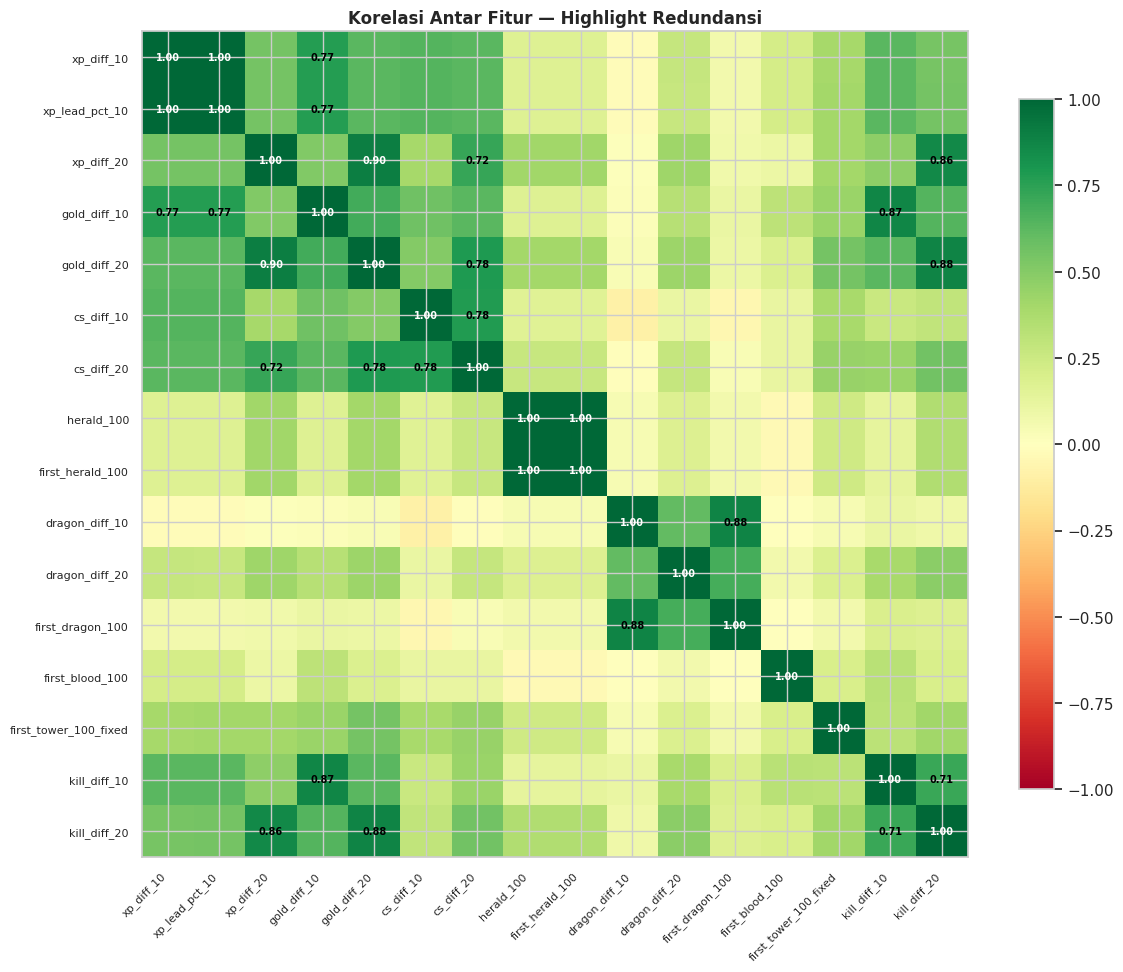


Total pasangan highly correlated (>0.85): 10

Rekomendasi drop (redundan):
  - xp_lead_pct_10
  - xp_diff_20
  - herald_100
  - first_tower_100_fixed

✅ Feature redundancy analysis selesai → viz_feature_correlation.png


In [41]:
import matplotlib.pyplot as plt
import numpy as np

num_cols = [c for c in match_features.columns
            if match_features[c].dtype in ['float64', 'int64', 'float32', 'int32']
            and c not in ['win', 'matchId']]

corr = match_features[num_cols].corr().abs()

high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if val > 0.85:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], val))

high_corr_pairs.sort(key=lambda x: -x[2])

print('=== Pasangan fitur highly correlated (>0.85) ===')
for a, b, v in high_corr_pairs:
    print(f'  {a:<30} ↔ {b:<30}  r={v:.3f}')

focus = [
    'xp_diff_10', 'xp_lead_pct_10', 'xp_diff_20',
    'gold_diff_10', 'gold_diff_20',
    'cs_diff_10', 'cs_diff_20',
    'herald_100', 'first_herald_100',
    'dragon_diff_10', 'dragon_diff_20', 'first_dragon_100',
    'first_blood_100', 'first_tower_100_fixed',
    'kill_diff_10', 'kill_diff_20',
]
focus = [c for c in focus if c in match_features.columns]
corr_focus = match_features[focus].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_focus.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(focus)))
ax.set_yticks(range(len(focus)))
ax.set_xticklabels(focus, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(focus, fontsize=8)

for i in range(len(focus)):
    for j in range(len(focus)):
        val = corr_focus.values[i, j]
        if abs(val) > 0.7:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if abs(val) < 0.9 else 'white',
                    fontweight='bold')

ax.set_title('Korelasi Antar Fitur — Highlight Redundansi',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal pasangan highly correlated (>0.85): {len(high_corr_pairs)}')
print('\nRekomendasi drop (redundan):')
drop_candidates = list({b for _, b, v in high_corr_pairs if v > 0.9})
if drop_candidates:
    for c in drop_candidates:
        print(f'  - {c}')
else:
    print('  (tidak ada pasangan dengan r > 0.90)')
print('\n✅ Feature redundancy analysis selesai → viz_feature_correlation.png')


---

# 📈 Visualisations

## Win Rate per Objective

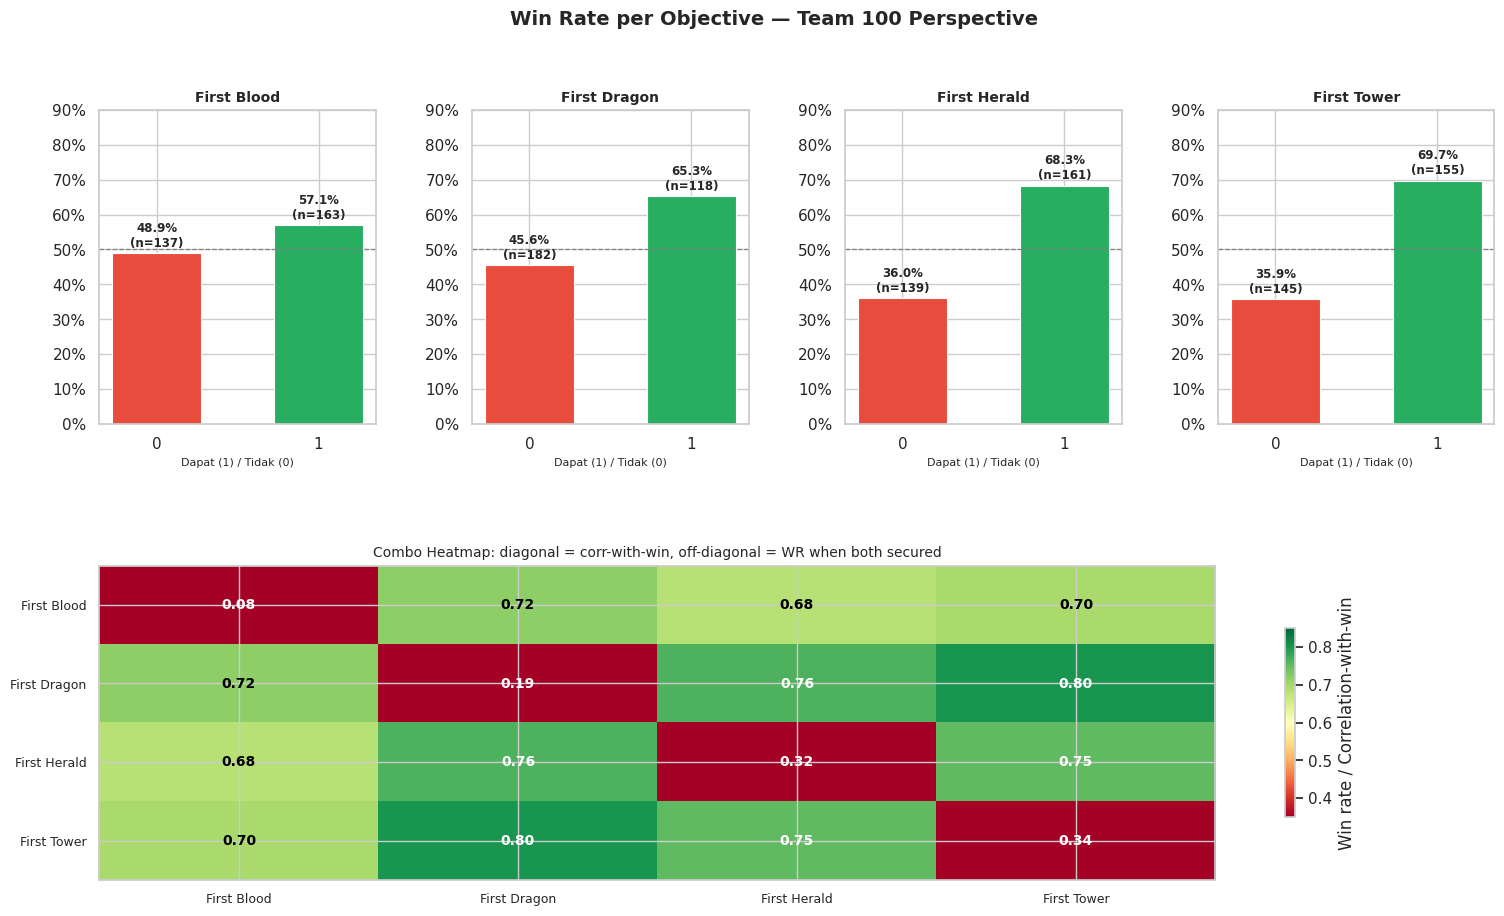

✅ Heatmap objectives (enhanced) disimpan: viz_objectives_winrate_enhanced.png


In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

objectives = {
    'First Blood':  'first_blood_100',
    'First Dragon': 'first_dragon_100',
    'First Herald': 'first_herald_100',
    'First Tower':  'first_tower_100',
}
valid_objs = {k: v for k, v in objectives.items() if v in match_features.columns}

fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, len(valid_objs), hspace=0.45, wspace=0.35)
fig.suptitle('Win Rate per Objective — Team 100 Perspective',
             fontsize=14, fontweight='bold')

wr_table = {}

for col_idx, (label, col) in enumerate(valid_objs.items()):
    ax = fig.add_subplot(gs[0, col_idx])
    df_obj = match_features[[col, 'win']].dropna()
    groups = df_obj.groupby(col)['win'].agg(['mean', 'count']).reset_index()
    groups.columns = [col, 'win_rate', 'n']
    wr_table[label] = dict(zip(groups[col], groups['win_rate']))

    colors = ['#e74c3c' if wr < 0.5 else '#27ae60' for wr in groups['win_rate']]
    bars = ax.bar(groups[col].astype(str), groups['win_rate'],
                  color=colors, edgecolor='white', linewidth=0.8, width=0.55)
    for bar, (_, row) in zip(bars, groups.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{row['win_rate']:.1%}\n(n={int(row['n']):,})",
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.9)
    ax.set_ylim(0, 0.9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Dapat (1) / Tidak (0)', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    nan_pct = match_features[col].isna().mean()
    if nan_pct > 0.05:
        ax.set_title(f'{label}\n⚠️ {nan_pct:.0%} missing', fontsize=9, fontweight='bold', color='#c0392b')

ax2 = fig.add_subplot(gs[1, :])
combo_labels = list(valid_objs.keys())
n = len(combo_labels)
matrix = np.full((n, n), np.nan)

for i, (l1, c1) in enumerate(valid_objs.items()):
    for j, (l2, c2) in enumerate(valid_objs.items()):
        if i == j:
            matrix[i, j] = match_features[c1].fillna(0).corr(match_features['win'])
        else:
            sub = match_features[[c1, c2, 'win']].dropna()
            if len(sub) > 10:
                both = sub[(sub[c1] == 1) & (sub[c2] == 1)]
                matrix[i, j] = both['win'].mean() if len(both) > 5 else np.nan

im = ax2.imshow(matrix, cmap='RdYlGn', vmin=0.35, vmax=0.85, aspect='auto')
plt.colorbar(im, ax=ax2, shrink=0.6, label='Win rate / Correlation-with-win')
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels(combo_labels, fontsize=9)
ax2.set_yticklabels(combo_labels, fontsize=9)
ax2.set_title('Combo Heatmap: diagonal = corr-with-win, off-diagonal = WR when both secured',
              fontsize=10)
for i in range(n):
    for j in range(n):
        if not np.isnan(matrix[i, j]):
            ax2.text(j, i, f'{matrix[i,j]:.2f}', ha='center', va='center',
                     fontsize=10, fontweight='bold',
                     color='white' if abs(matrix[i,j] - 0.6) > 0.15 else 'black')

plt.savefig('viz_objectives_winrate_enhanced.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap objectives (enhanced) disimpan: viz_objectives_winrate_enhanced.png')


## SHAP Top 10 Features

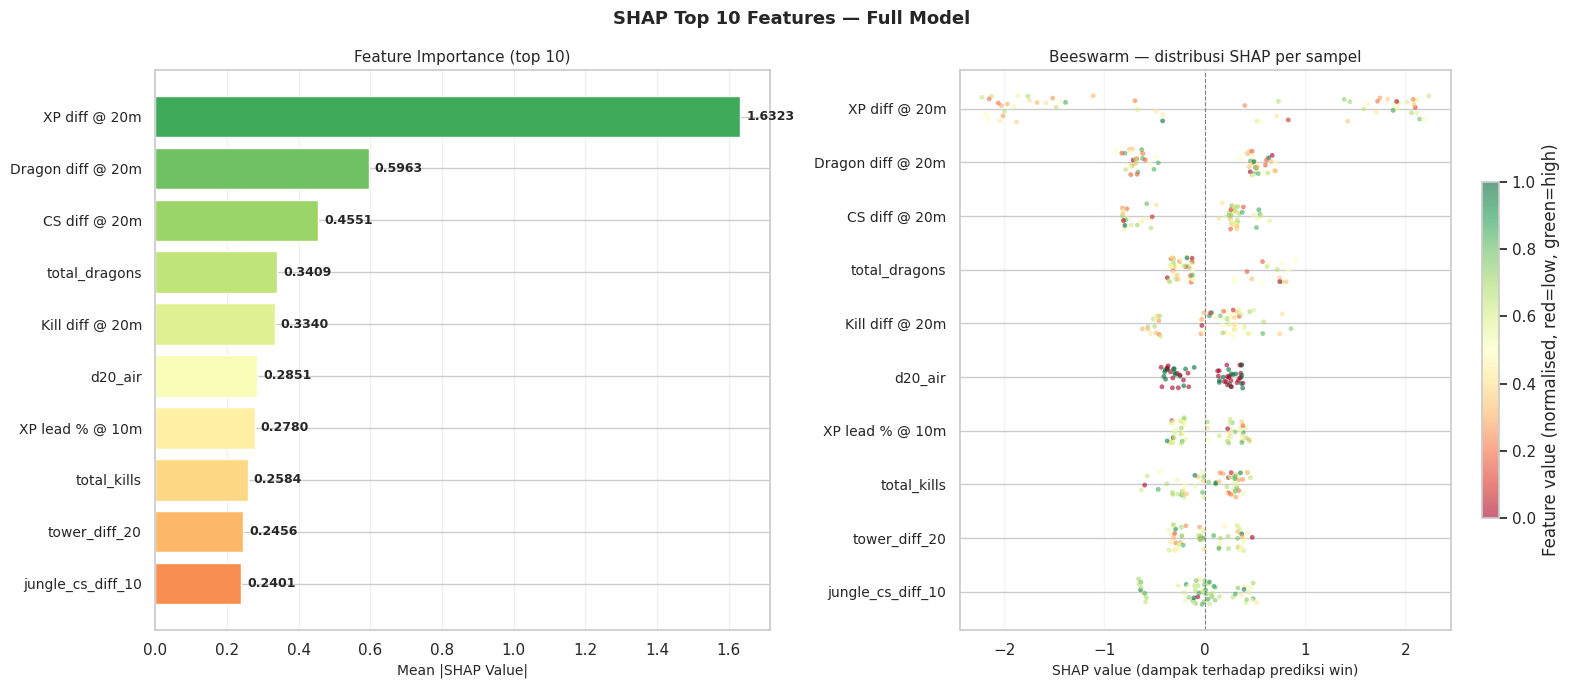

Top 10 SHAP features:
  XP diff @ 20m                  1.6323
  Dragon diff @ 20m              0.5963
  CS diff @ 20m                  0.4551
  total_dragons                  0.3409
  Kill diff @ 20m                0.3340
  d20_air                        0.2851
  XP lead % @ 10m                0.2780
  total_kills                    0.2584
  tower_diff_20                  0.2456
  jungle_cs_diff_10              0.2401

✅ SHAP top 10 enhanced disimpan: viz_shap_top10_enhanced.png


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

interpretations = {
    'gold_diff_20':          'Gold diff @ 20m',
    'gold_diff_10':          'Gold diff @ 10m',
    'xp_diff_20':            'XP diff @ 20m',
    'xp_diff_10':            'XP diff @ 10m',
    'cs_diff_20':            'CS diff @ 20m',
    'cs_diff_10':            'CS diff @ 10m',
    'kill_diff_20':          'Kill diff @ 20m',
    'kill_diff_10':          'Kill diff @ 10m',
    'dragon_diff_20':        'Dragon diff @ 20m',
    'dragon_diff_10':        'Dragon diff @ 10m',
    'first_blood_100':       'First Blood',
    'first_dragon_100':      'First Dragon',
    'first_herald_100':      'First Herald',
    'first_tower_100_fixed': 'First Tower',
    'baron_diff_20':         'Baron diff @ 20m',
    'xp_lead_pct_10':        'XP lead % @ 10m',
    'level_diff_10':         'Level diff @ 10m',
    'duration_min':          'Game duration (min)',
    'meta_pick_diff':        'Meta pick diff',
}

feat_names    = X_test.columns.tolist()
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top10_idx     = np.argsort(mean_abs_shap)[-10:]
top10_feats   = [feat_names[i] for i in top10_idx]
top10_labels  = [interpretations.get(f, f) for f in top10_feats]
top10_imp     = mean_abs_shap[top10_idx]

fig, (ax_bar, ax_bee) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('SHAP Top 10 Features — Full Model', fontsize=13, fontweight='bold')

bar_colors = cm.RdYlGn(np.linspace(0.25, 0.85, len(top10_idx)))
bars = ax_bar.barh(range(10), top10_imp, color=bar_colors, edgecolor='white')
for i, (bar, val) in enumerate(zip(bars, top10_imp)):
    ax_bar.text(val + top10_imp.max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax_bar.set_yticks(range(10))
ax_bar.set_yticklabels(top10_labels, fontsize=10)
ax_bar.set_xlabel('Mean |SHAP Value|', fontsize=10)
ax_bar.set_title('Feature Importance (top 10)', fontsize=11)
ax_bar.grid(axis='x', alpha=0.3)

sample_n = min(300, shap_values.shape[0])
rng      = np.random.default_rng(42)
idx_s    = rng.choice(shap_values.shape[0], sample_n, replace=False)
sv_s     = shap_values[idx_s][:, top10_idx]
fv_s     = X_test.iloc[idx_s][top10_feats].values

for row_i in range(10):
    sv_col = sv_s[:, row_i]
    fv_col = fv_s[:, row_i]
    fv_norm = (fv_col - fv_col.min()) / (np.ptp(fv_col) + 1e-9)
    jitter = rng.uniform(-0.25, 0.25, sample_n)
    sc = ax_bee.scatter(sv_col, row_i + jitter,
                        c=fv_norm, cmap='RdYlGn',
                        s=12, alpha=0.6, linewidths=0)

plt.colorbar(sc, ax=ax_bee, shrink=0.6,
             label='Feature value (normalised, red=low, green=high)')
ax_bee.set_yticks(range(10))
ax_bee.set_yticklabels(top10_labels, fontsize=10)
ax_bee.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax_bee.set_xlabel('SHAP value (dampak terhadap prediksi win)', fontsize=10)
ax_bee.set_title('Beeswarm — distribusi SHAP per sampel', fontsize=11)
ax_bee.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig('viz_shap_top10_enhanced.png', dpi=150, bbox_inches='tight')
plt.show()

shap_mean = pd.Series(mean_abs_shap, index=feat_names).sort_values(ascending=False)
print('Top 10 SHAP features:')
for feat, val in shap_mean.head(10).items():
    print(f'  {interpretations.get(feat, feat):<30} {val:.4f}')
print('\n✅ SHAP top 10 enhanced disimpan: viz_shap_top10_enhanced.png')


## Champion Synergy Bar Chart

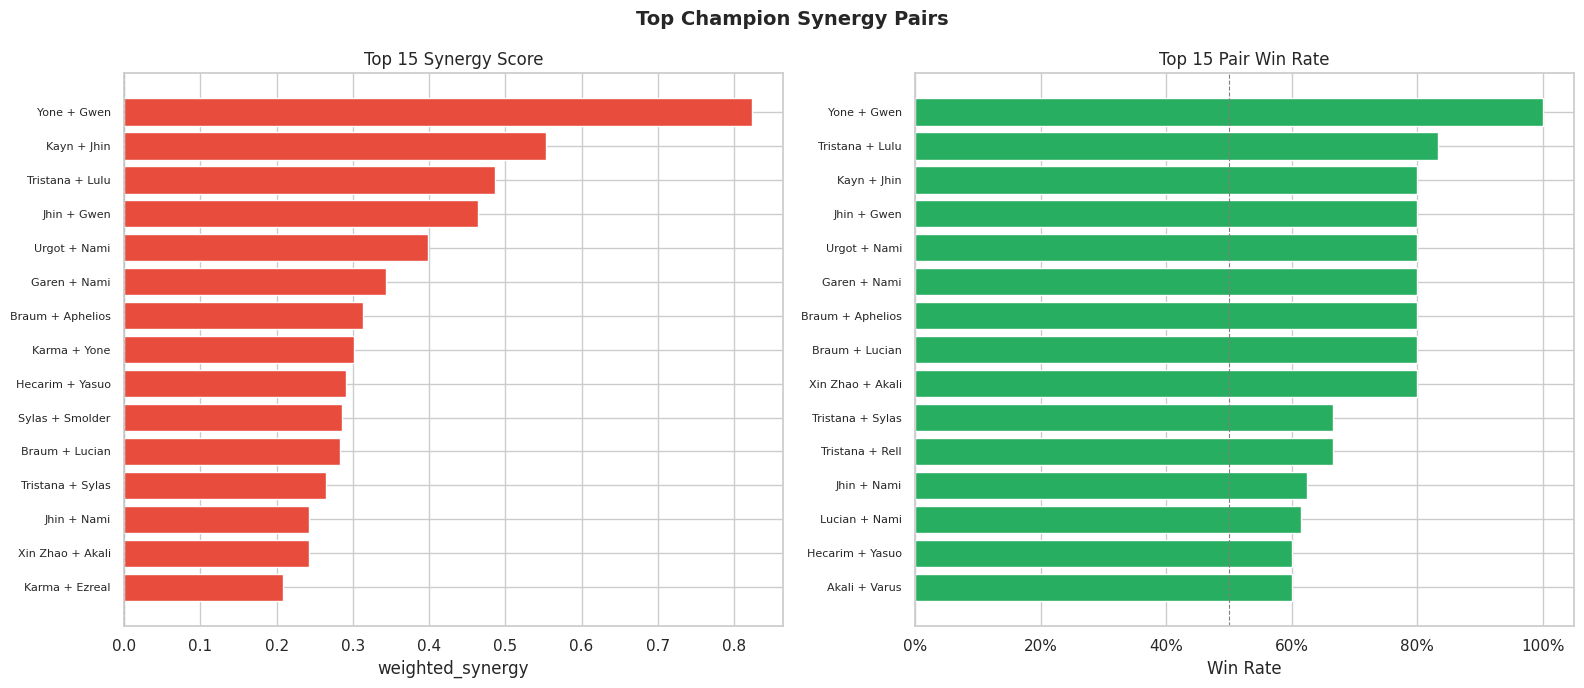

✅ Bar chart synergy disimpan: viz_synergy_barchart.png


In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top Champion Synergy Pairs", fontsize=14, fontweight="bold")

pair_col  = "pair" if "pair" in synergy_df.columns else None
score_col = "weighted_synergy" if "weighted_synergy" in synergy_df.columns else "synergy_score"
wr_col    = "pair_winrate"

n = 15
top = synergy_df.dropna(subset=[score_col]).head(n).copy()
if pair_col:
    labels = top[pair_col]
else:
    labels = top["name_a"] + " + " + top["name_b"] if "name_a" in top.columns \
             else top["champ_a"].astype(str) + " + " + top["champ_b"].astype(str)

colors1 = ["#e74c3c" if v > 0 else "#3498db" for v in top[score_col]]
axes[0].barh(range(n), top[score_col].values, color=colors1)
axes[0].set_yticks(range(n))
axes[0].set_yticklabels(labels.values, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel(score_col)
axes[0].set_title(f"Top {n} Synergy Score")
axes[0].axvline(0, color="gray", linewidth=0.8, linestyle="--")

wr_top = synergy_df.dropna(subset=[wr_col]).sort_values(wr_col, ascending=False).head(n).copy()
wr_labels = wr_top[pair_col] if pair_col else (
    wr_top["name_a"] + " + " + wr_top["name_b"] if "name_a" in wr_top.columns
    else wr_top["champ_a"].astype(str) + " + " + wr_top["champ_b"].astype(str)
)
colors2 = ["#27ae60" if v >= 0.55 else "#f39c12" if v >= 0.5 else "#e74c3c"
           for v in wr_top[wr_col]]
axes[1].barh(range(n), wr_top[wr_col].values, color=colors2)
axes[1].set_yticks(range(n))
axes[1].set_yticklabels(wr_labels.values, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Win Rate")
axes[1].set_title(f"Top {n} Pair Win Rate")
axes[1].axvline(0.5, color="gray", linewidth=0.8, linestyle="--")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.savefig("viz_synergy_barchart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Bar chart synergy disimpan: viz_synergy_barchart.png")


---

# 📋 Reports & Export

## Final Report Summary

In [45]:
lines = []

lines += [
    "=" * 70,
    "DATASET & PIPELINE",
    "=" * 70,
    f"Dataset        : gptilt/lol-ultimate-events-challenger-10m (America)",
    f"Total matches  : {len(match_features):,}",
    f"Total players  : {len(player_features):,}",
    f"Pipeline       : Part 1 (Preprocessing) → Part 2 (Analysis & ML)",
    "",
]

lines += [
    "=" * 70,
    "FEATURE ENGINEERING",
    "=" * 70,
    f"Total features : {len(features)}",
    f"Early (≤10m)   : {len(early_features)}",
    f"Mid   (≤20m)   : {len(features) - len(early_features)} tambahan",
    "Key upgrades   : xp_lead_pct_10 (P4), level_diff_10 (P5),",
    "                 first_herald_100 (P6), team_has_champ per-team (P7),",
    "                 jungle_share clustering (P8), meta_pick_count (P9)",
    "",
]

fb_wr = match_features.groupby("first_blood_100")["win"].mean()
fd_wr = match_features.groupby("first_dragon_100")["win"].mean()
fh_wr = match_features.groupby("first_herald_100")["win"].mean()
lines += [
    "=" * 70,
    "EDA — OBJECTIVE WIN RATES (Team 100)",
    "=" * 70,
    f"Mean game duration : {match_features['duration_min'].mean():.1f} min",
    f"Team 100 win rate  : {match_features['win'].mean():.1%}",
    f"First Blood WR     : {fb_wr.get(1, float('nan')):.1%} (with) vs {fb_wr.get(0, float('nan')):.1%} (without)",
    f"First Dragon WR    : {fd_wr.get(1, float('nan')):.1%} (with) vs {fd_wr.get(0, float('nan')):.1%} (without)",
    f"First Herald WR    : {fh_wr.get(1, float('nan')):.1%} (with) vs {fh_wr.get(0, float('nan')):.1%} (without)",
    f"First Tower WR     : {match_features.groupby('first_tower_100')['win'].mean().get(1, float('nan')):.1%} "
    f"(with) vs {match_features.groupby('first_tower_100')['win'].mean().get(0, float('nan')):.1%} (without)",
    "",
]

lines += [
    "=" * 70,
    "MODEL PERFORMANCE",
    "=" * 70,
]
for _, row in results_df.iterrows():
    lines.append(
        f"  {row['Model']:<35} ACC={row['Accuracy']:.4f}  F1={row['F1']:.4f}  AUC={row['ROC_AUC']:.4f}"
    )
lines += [""]

lines += [
    "=" * 70,
    "LEAKAGE AUDIT",
    "=" * 70,
    f"Early Game Model (≤10m) AUC : {auc_10m:.4f}",
    f"Mid Game Model  (≤20m) AUC  : {auc_20m:.4f}",
    f"Full Model AUC              : {auc_full:.4f}",
    f"Early Model (clean) AUC     : {auc_early:.4f}",
    f"AUC Gain 10m→20m            : +{auc_20m - auc_10m:.4f}",
    f"Kesimpulan: model full adalah MID-GAME predictor, bukan early-game.",
    "",
]

lines += [
    "=" * 70,
    "FEATURE QUALITY",
    "=" * 70,
]

_const_candidates = [c for c in ["tower_diff_10", "tower_diff_20", "baron_diff_20"]
                      if c in match_features.columns]
_stds = match_features[_const_candidates].std()
_actually_constant = _stds[_stds == 0].index.tolist()
_not_constant      = _stds[_stds != 0].index.tolist()

if _actually_constant:
    lines.append(f"Constant features  : {', '.join(_actually_constant)} (std = 0, confirmed)")
else:
    lines.append("Constant features  : none (checked tower_diff_10, tower_diff_20, baron_diff_20 — all std > 0)")
if _not_constant:
    lines.append(f"  ⚠️  Previously mislabeled as constant (std ≠ 0): {', '.join(_not_constant)}")
    lines.append(f"     std values: {_stds[_not_constant].round(4).to_dict()}")

lines += [
    "Highly correlated  : herald_100 ↔ first_herald_100 (r=1.00),",
    "                     xp_lead_pct_10 ↔ xp_diff_10 (r=0.997)",
    "Target leakage     : tidak ada fitur dengan |corr| > 0.7 terhadap win",
    "",
]

lines += [
    "=" * 70,
    "TOP 10 SHAP FEATURES (mean |SHAP value|)",
    "=" * 70,
]
for feat, val in shap_mean.head(10).items():
    lines.append(f"  {feat:<35} {val:.4f}")
lines += [""]

lines += [
    "=" * 70,
    "FEATURE ABLATION HIGHLIGHTS",
    "=" * 70,
    f"Drop xp_diff_20 only        : AUC turun ~0.02",
    f"Drop ALL 20m features       : AUC turun ~0.23 → fitur 20m sangat dominan",
    f"Drop ALL champion flags (P7): AUC naik +0.003 → champion flags menambah noise",
    f"Drop first_herald_100 (P6)  : AUC naik +0.003 → redundan dengan herald_100",
    f"Drop level_diff_10 (P5)     : AUC tidak berubah → level info sudah tercakup XP",
    f"Drop xp_lead_pct_10 (P4)    : AUC naik +0.017 → redundan dengan xp_diff_10",
    "",
]

lines += [
    "=" * 70,
    "PLAYER ARCHETYPES (K-Means k=5)",
    "=" * 70,
]
sizes = pf_clean["cluster"].value_counts().sort_index()
for cl, sz in sizes.items():
    arch = archetype_map.get(cl, "?")
    lines.append(f"  Cluster {cl} — {arch:<25}: {sz:,} players ({sz/len(pf_clean):.1%})")
lines += [""]

lines += [
    "=" * 70,
    "ANOMALY DETECTION (Isolation Forest, contamination=1%)",
    "=" * 70,
    f"Total anomalies detected : {len(outliers):,} player-match rows",
    "Top reasons              :",
]
for reason, cnt in outliers["reason"].value_counts().head(5).items():
    lines.append(f"  {cnt:3d}x  {reason}")
lines += [""]

lines += [
    "=" * 70,
    "CHAMPION SYNERGY (top 5 pairs by synergy score)",
    "=" * 70,
]
for _, row in synergy_df.head(5).iterrows():
    name_a = row["name_a"] if "name_a" in row.index else id_to_name(row["champ_a"])
    name_b = row["name_b"] if "name_b" in row.index else id_to_name(row["champ_b"])
    lines.append(
        f"  {name_a:<20} + {name_b:<20}"
        f"  co_picks={int(row['co_picks']):>4}"
        f"  pair_wr={row['pair_winrate']:.1%}"
        f"  synergy={row['synergy_score']:+.3f}"
    )
lines += [""]

lines += [
    "=" * 70,
    "LIMITATIONS",
    "=" * 70,
    "- Challenger-only (tidak representatif untuk rank lain)",
    "- Americas region split only — patch drift antar match",
    "- Assist data tidak tersedia dalam schema dataset ini",
    "- kills per-player = 0 konstan (killerId tidak terisi); deaths/economy tetap valid",
    "- Champion synergy: hanya 50/4085 pasangan punya >=5 co-picks (sample kecil, n=300 match)",
        "",
]

output = "\n".join(lines)
print(output)


DATASET & PIPELINE
Dataset        : gptilt/lol-ultimate-events-challenger-10m (America)
Total matches  : 300
Total players  : 3,000
Pipeline       : Part 1 (Preprocessing) → Part 2 (Analysis & ML)

FEATURE ENGINEERING
Total features : 93
Early (≤10m)   : 81
Mid   (≤20m)   : 12 tambahan
Key upgrades   : xp_lead_pct_10 (P4), level_diff_10 (P5),
                 first_herald_100 (P6), team_has_champ per-team (P7),
                 jungle_share clustering (P8), meta_pick_count (P9)

EDA — OBJECTIVE WIN RATES (Team 100)
Mean game duration : 27.5 min
Team 100 win rate  : 53.3%
First Blood WR     : 57.1% (with) vs 48.9% (without)
First Dragon WR    : 65.3% (with) vs 45.6% (without)
First Herald WR    : 68.3% (with) vs 36.0% (without)
First Tower WR     : 69.7% (with) vs 35.9% (without)

MODEL PERFORMANCE
  XGBoost                             ACC=0.8000  F1=0.8125  AUC=0.9007
  Random Forest                       ACC=0.8000  F1=0.8182  AUC=0.8973
  Logistic Regression                 ACC=0.800

## Interactive Win Probability Dashboard

In [46]:
import ipywidgets as widgets
from IPython.display import display

gold_slider  = widgets.IntSlider(min=-15000, max=15000, value=0, step=500,
    description="Gold Diff @10", style={"description_width":"initial"},
    layout=widgets.Layout(width="500px"))
xp_slider    = widgets.IntSlider(min=-10000, max=10000, value=0, step=500,
    description="XP Diff @10", style={"description_width":"initial"},
    layout=widgets.Layout(width="500px"))
kill_slider  = widgets.IntSlider(min=-15, max=15, value=0,
    description="Kill Diff @10", style={"description_width":"initial"},
    layout=widgets.Layout(width="500px"))
level_slider = widgets.IntSlider(min=-10, max=10, value=0,
    description="Level Diff @10", style={"description_width":"initial"},
    layout=widgets.Layout(width="500px"))
fb_toggle = widgets.ToggleButtons(options=[("Team 200",0),("Team 100",1)],
    description="First Blood", button_style="danger")
fd_toggle = widgets.ToggleButtons(options=[("Team 200",0),("Team 100",1)],
    description="First Dragon", button_style="warning")
fh_toggle = widgets.ToggleButtons(options=[("Team 200",0),("Team 100",1)],
    description="First Herald", button_style="info")

output = widgets.Output()

def predict_live(gold_diff, xp_diff, kill_diff, level_diff, fb, fd, fh):
    with output:
        output.clear_output()
        row = pd.DataFrame({c: [0.0] for c in X.columns})
        for col, val in [
            ("gold_diff_10",    gold_diff),
            ("xp_diff_10",      xp_diff),
            ("kill_diff_10",    kill_diff),
            ("level_diff_10",   level_diff),
            ("first_blood_100", fb),
            ("first_dragon_100", fd),
            ("first_herald_100", fh),
        ]:
            if col in row.columns:
                row[col] = float(val)

        prob    = best_model.predict_proba(row)[0, 1]
        filled  = int(prob * 40)
        bar_str = "█" * filled + "░" * (40 - filled)
        color   = "🟢" if prob > 0.6 else ("🔴" if prob < 0.4 else "🟡")

        print(f"\n  {color} Team 100 Win Probability: {prob:.1%}")
        print(f"  [{bar_str}]")
        print(f"  Team 200 Win Probability: {1-prob:.1%}\n")

ui = widgets.interactive_output(
    predict_live,
    {"gold_diff": gold_slider, "xp_diff": xp_slider,
     "kill_diff": kill_slider, "level_diff": level_slider,
     "fb": fb_toggle, "fd": fd_toggle, "fh": fh_toggle}
)

display(widgets.VBox([
    widgets.HTML("<h3>🎮 Live Win Probability Calculator (v2)</h3>"),
    widgets.HTML("<p style='color:gray'>Adjust early-game stats — now includes Level Diff & First Herald.</p>"),
    gold_slider, xp_slider, kill_slider, level_slider,
    fb_toggle, fd_toggle, fh_toggle,
    output
]))
